# **Проверка гипотез.**

## Подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon

In [ ]:
# совместный датасет для выборок 300/1500/3000/8000 образцов в классе
df = pd.read_csv("exp_results_8000.csv")
df

,dataset,model,method,modules,rank,time,gpu,loss,f1,accuracy,pst_dataset
0,EN,qwen2.5,baseline,NaN,NaN,6.909377,3.088264,272.000000,0.593866,0.603421,8000
1,EN,qwen2.5,LoRA,q+v,4.0,16.333922,5.651793,5.121094,0.914616,0.914737,8000
2,EN,qwen2.5,LoRA,q+v,8.0,16.314592,5.655288,0.316895,0.930126,0.930132,8000
3,EN,qwen2.5,LoRA,q+v,16.0,16.328842,5.661056,0.273926,0.934788,0.934868,8000
4,EN,qwen2.5,LoRA,q+v,32.0,16.849067,5.679749,0.260742,0.932327,0.932368,8000
...,...,...,...,...,...,...,...,...,...,...,...
587,RU,qwen3,QLoRA fp4,q+k+v,32.0,2.645973,4.757506,0.551760,0.804386,0.803945,300
588,RU,qwen3,QLoRA fp4,q+k+v+o,4.0,2.781251,4.841617,1.075496,0.527577,0.537263,300
589,RU,qwen3,QLoRA fp4,q+k+v+o,8.0,2.732979,4.863017,0.858874,0.655355,0.660862,300
590,RU,qwen3,QLoRA fp4,q+k+v+o,16.0,2.719546,4.889461,0.563589,0.798812,0.798831,300


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dataset      592 non-null    object 
 1   model        592 non-null    object 
 2   method       592 non-null    object 
 3   modules      576 non-null    object 
 4   rank         576 non-null    float64
 5   time         592 non-null    float64
 6   gpu          592 non-null    float64
 7   loss         592 non-null    float64
 8   f1           592 non-null    float64
 9   accuracy     592 non-null    float64
 10  pst_dataset  592 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 51.0+ KB


In [ ]:
# отдельно русскоязычный и англоязычный датасет
df_en = df[df['dataset']=='EN']
df_ru = df[df['dataset']=='RU']

## Функции для расчетов

In [ ]:
def plot_accuracy_vs_dataset_size(df, methods, dataset_name='AG_News', models=['qwen2.5', 'qwen3']):
    """
    Строит график зависимости accuracy от размера датасета для указанных методов.

    Parameters:
    -----------
    df : DataFrame
        Исходный DataFrame с данными
    methods : list или str
        Список методов для фильтрации (например, ['QLoRA fp4']) или строка с одним методом
    dataset_name : str
        Название датасета для фильтрации (поле 'dataset' в df)
    models : list
        Список моделей для фильтрации (по умолчанию ['qwen2.5', 'qwen3'])

    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Если methods передан как строка, преобразуем в список
    if isinstance(methods, str):
        methods = [methods]

    # Фильтрация по модели, методу и датасету
    df_filtered = df[
        (df['model'].isin(models)) &
        (df['method'].isin(methods)) &
        (df['dataset'] == dataset_name)
    ]

    # Усреднение accuracy
    df_avg = (
        df_filtered
        .groupby(['model', 'method', 'pst_dataset'])['accuracy']
        .mean()
        .reset_index()
    )

    # Построение графика
    fig, ax = plt.subplots(figsize=(6, 3))

    for (model, method), group in df_avg.groupby(['model', 'method']):
        label = f"{model} - {method}"
        ax.plot(group['pst_dataset'], group['accuracy'], marker='.', label=label, linewidth=2, markersize=8)

    ax.set_xlabel('Кол-во образцов в одном классе обуч.выборки', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Accuracy vs Dataset Size for {", ".join(methods)} ({dataset_name})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, ax

In [ ]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(
        ((nx - 1)*np.std(x, ddof=1)**2 + (ny - 1)*np.std(y, ddof=1)**2) / dof
    )

def run_test(group1, group2, metric_name):
    # Проверка нормальности
    p1 = stats.shapiro(group1)[1] if len(group1) < 5000 else 1
    p2 = stats.shapiro(group2)[1] if len(group2) < 5000 else 1

    normal = (p1 > 0.05) and (p2 > 0.05)

    if normal:
        stat, p = stats.ttest_ind(group1, group2, equal_var=False)
        test_name = "t-test"
    else:
        stat, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        test_name = "Mann-Whitney"

    d = cohens_d(group1, group2)

    print(f"\n=== {metric_name} ===")
    print(f"Test: {test_name}")
    print(f"p-value: {p:.6f}")
    print(f"Effect size (Cohen's d): {d:.3f}")
    print(f"Mean Qwen2.5: {np.mean(group1):.4f}")
    print(f"Mean Qwen3:  {np.mean(group2):.4f}")

    if p < 0.05:
        print("Статистически значимо")
    else:
        print("НЕ значимо")

In [ ]:
# Берём только эксперименты с rank
rank_df = df.copy()
rank_df = rank_df.dropna(subset=['rank', 'accuracy'])

# Убираем baseline
rank_df = rank_df[rank_df['method'] != 'baseline']

# Приводим rank к int
rank_df['rank'] = rank_df['rank'].astype(int)

# **Гипотезы**

##**H1**: Qwen2.5-1.5B показывает сопоставимое или лучшее качество при достаточном объёме данных (более 1500 образцов в каждом классе обучающей выборки).

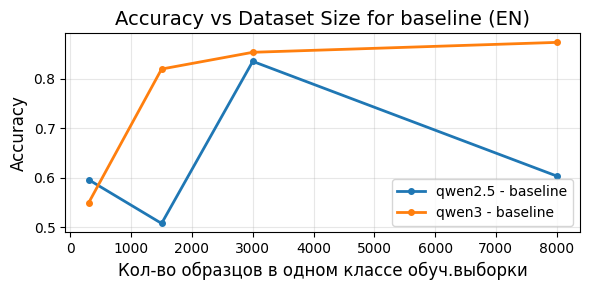

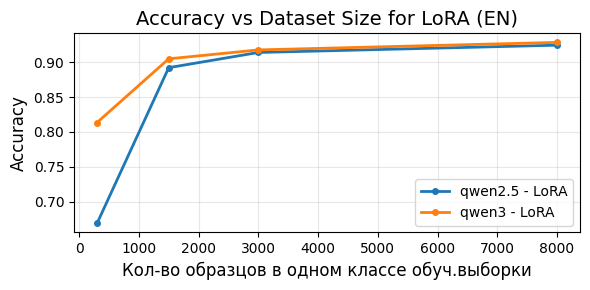

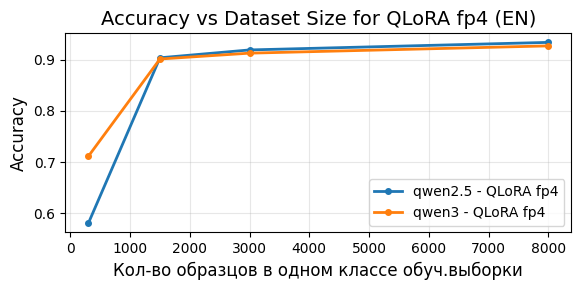

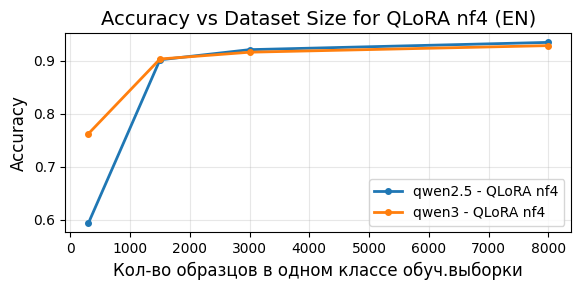

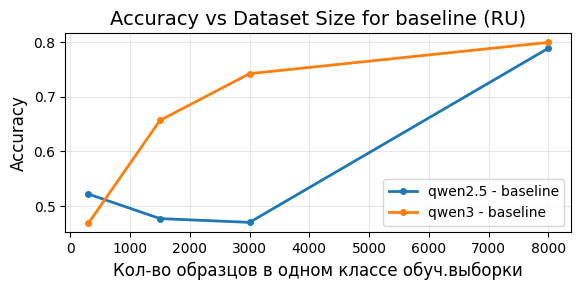

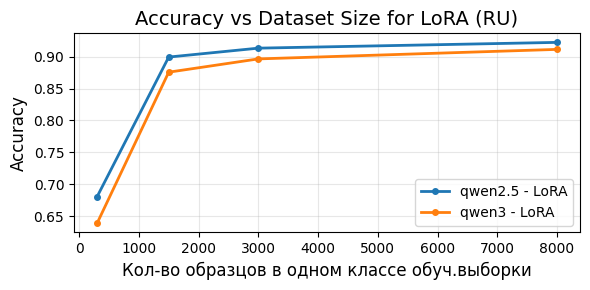

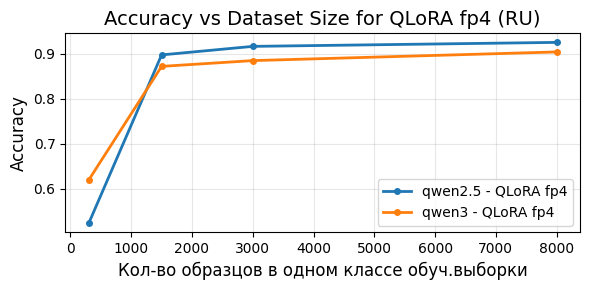

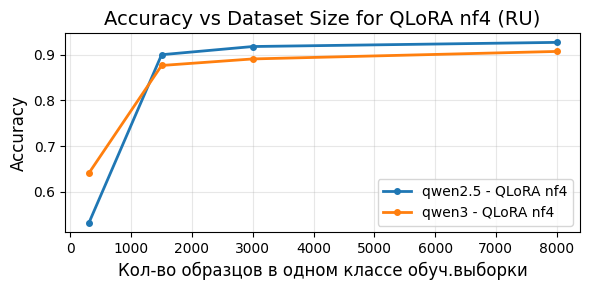

(<Figure size 600x300 with 1 Axes>,
 <Axes: title={'center': 'Accuracy vs Dataset Size for QLoRA nf4 (RU)'}, xlabel='Кол-во образцов в одном классе обуч.выборки', ylabel='Accuracy'>)

In [ ]:
# 1. Baseline / En
plot_accuracy_vs_dataset_size(df, methods='baseline', dataset_name='EN')

# 2. LoRA / En
plot_accuracy_vs_dataset_size(df, methods='LoRA', dataset_name='EN')

# 3. QLoRA fp4 / En
plot_accuracy_vs_dataset_size(df, methods='QLoRA fp4', dataset_name='EN')

# 4. QLoRA nf4 / En
plot_accuracy_vs_dataset_size(df, methods='QLoRA nf4', dataset_name='EN')

# 5. Baseline / Ru
plot_accuracy_vs_dataset_size(df, methods='baseline', dataset_name='RU')

# 6. LoRA / Ru
plot_accuracy_vs_dataset_size(df, methods='LoRA', dataset_name='RU')

# 7. QLoRA fp4 / Ru
plot_accuracy_vs_dataset_size(df, methods='QLoRA fp4', dataset_name='RU')

# 8. QLoRA nf4 / Ru
plot_accuracy_vs_dataset_size(df, methods='QLoRA nf4', dataset_name='RU')

- qwen2.5 (baseline): accuracy стартует с 0.50 , показывает нестабильный результат при увеличении выборки

- qwen3 (baseline): более стабильное поведение, низкие показатели на малых данных

Вывод: без тонкой настройки (fine-tuning) модели не способны эффективно решать задачу.

Далее рассмотрим на сколько значима разница моделей на разном объеме выборок при дообучениии методами LoRA и QLoRA

In [ ]:
# H1
# для EN
large_data = df_en[(df_en['pst_dataset'] >= 1500) & (df_en['method'] != 'baseline')]

qwen25 = large_data[large_data['model'] == 'qwen2.5']['accuracy']
qwen3 = large_data[large_data['model'] == 'qwen3']['accuracy']

print("Qwen2.5 vs Qwen3 на больших данных (EN)")
run_test(qwen25, qwen3, "Accuracy")

# для RU
large_data = df_ru[(df_ru['pst_dataset'] >= 1500) & (df_ru['method'] != 'baseline')]

qwen25 = large_data[large_data['model'] == 'qwen2.5']['accuracy']
qwen3 = large_data[large_data['model'] == 'qwen3']['accuracy']

print("\nQwen2.5 vs Qwen3 на больших данных (RU)")
run_test(qwen25, qwen3, "Accuracy")

Qwen2.5 vs Qwen3 на больших данных (EN)

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.209371
Effect size (Cohen's d): 0.034
Mean Qwen2.5: 0.9158
Mean Qwen3:  0.9153
НЕ значимо

Qwen2.5 vs Qwen3 на больших данных (RU)

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.000000
Effect size (Cohen's d): 1.359
Mean Qwen2.5: 0.9131
Mean Qwen3:  0.8909
Статистически значимо


Для сравнения качества моделей использовался критерий Манна–Уитни, поскольку распределение метрик качества может отклоняться от нормального, а также присутствуют выбросы и неоднородность дисперсий.

Получено p < 0.05, что свидетельствует о наличии статистически значимых различий. Это значит, что модели статистичиески значимо различаются по качеству. Qwen2.5-1.5B показывает лучшее качество при достаточном объёме данных (более 1500 образцов в каждом классе обучающей выборки).

**Вывод: При дообучении методом LoRA и QLoRA Qwen2.5-1.5B чаще показывает сопоставимое или лучшее качество при достаточном объёме данных (более 1500 образцов в каждом классе обучающей выборки). Модели статистичиески значимо различаются по качеству.**

## **H2:** Qwen3-0.6B превосходит Qwen2.5-1.5B при 300 образцов в каждом классе обучающей выборки.

In [ ]:
# H2
# для EN
small_data = df_en[(df_en['pst_dataset'] < 1500) & (df_en['method'] != 'baseline')]

qwen25 = small_data[small_data['model'] == 'qwen2.5']['accuracy']
qwen3 = small_data[small_data['model'] == 'qwen3']['accuracy']

print("Qwen2.5 vs Qwen3 на малых данных (EN)")
run_test(qwen25, qwen3, "Accuracy")

# для RU
small_data = df_ru[(df_ru['pst_dataset'] < 1500) & (df_ru['method'] != 'baseline')]

qwen25 = small_data[small_data['model'] == 'qwen2.5']['accuracy']
qwen3 = small_data[small_data['model'] == 'qwen3']['accuracy']

print("\nQwen2.5 vs Qwen3 на малых данных (RU)")
run_test(qwen25, qwen3, "Accuracy")

Qwen2.5 vs Qwen3 на малых данных (EN)

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.000002
Effect size (Cohen's d): -1.266
Mean Qwen2.5: 0.6140
Mean Qwen3:  0.7621
Статистически значимо

Qwen2.5 vs Qwen3 на малых данных (RU)

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.124213
Effect size (Cohen's d): -0.389
Mean Qwen2.5: 0.5782
Mean Qwen3:  0.6328
НЕ значимо


Проведён Mann–Whitney тест. Получено p < 0.05, что свидетельствует о наличии статистически значимых различий, т.е. **Qwen3-0.6B превосходит Qwen2.5-1.5B по качеству при 300 образцов в каждом классе обучающей выборки.**

## **H3:** Qwen3-0.6B даёт более стабильные результаты (меньше разброс loss)

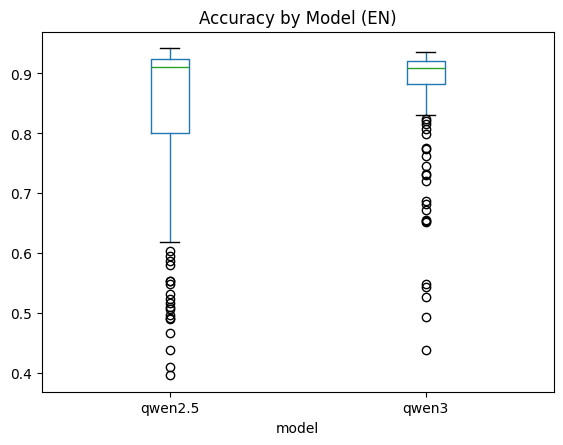

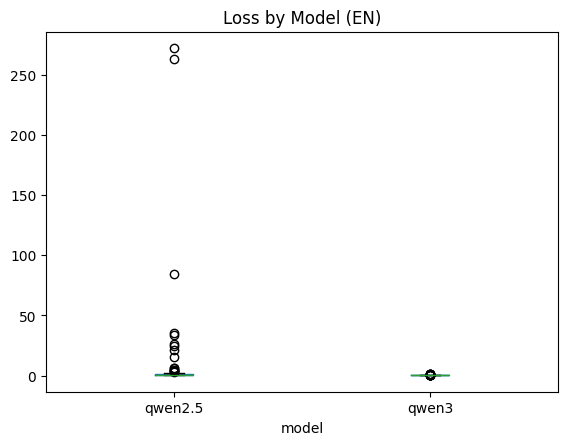

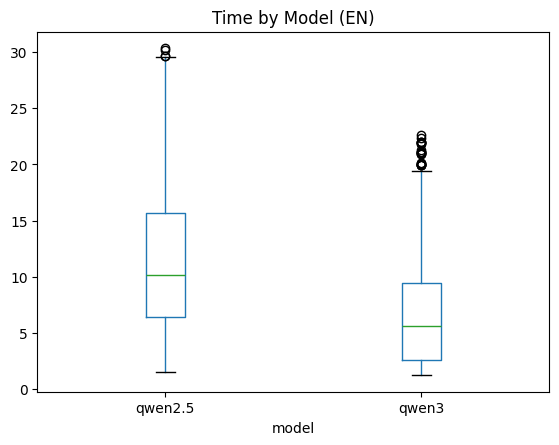

In [ ]:
# Accuracy boxplot
df_en.boxplot(column='accuracy', by='model', grid=False)
plt.title("Accuracy by Model (EN)")
plt.suptitle("")
plt.show()

# Loss boxplot
df_en.boxplot(column='loss', by='model', grid=False)
plt.title("Loss by Model (EN)")
plt.suptitle("")
plt.show()

# Time boxplot
df_en.boxplot(column='time', by='model', grid=False)
plt.title("Time by Model (EN)")
plt.suptitle("")
plt.show()

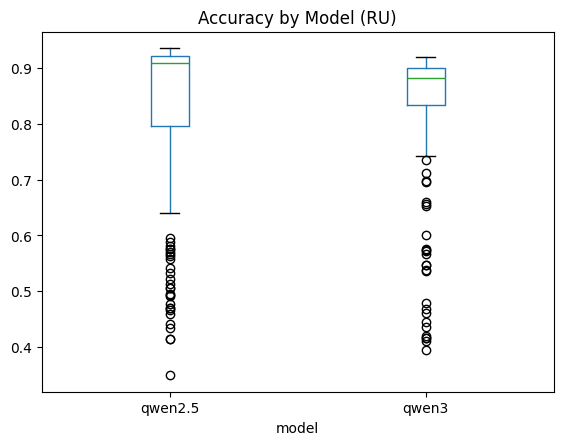

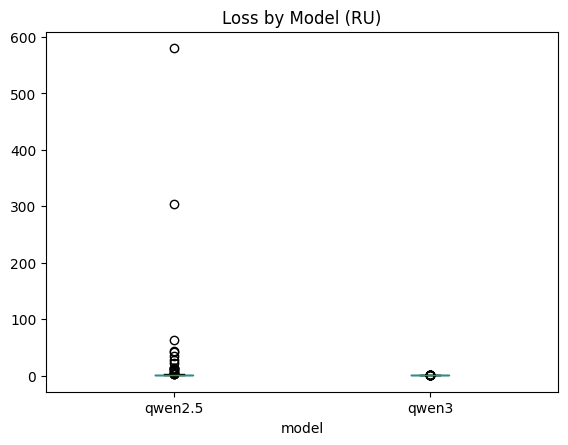

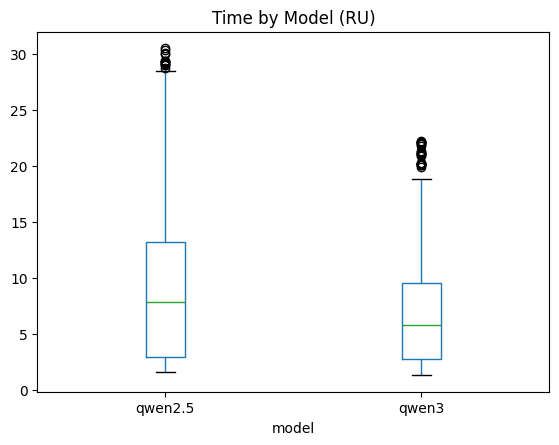

In [ ]:
# Accuracy boxplot
df_ru.boxplot(column='accuracy', by='model', grid=False)
plt.title("Accuracy by Model (RU)")
plt.suptitle("")
plt.show()

# Loss boxplot
df_ru.boxplot(column='loss', by='model', grid=False)
plt.title("Loss by Model (RU)")
plt.suptitle("")
plt.show()

# Time boxplot
df_ru.boxplot(column='time', by='model', grid=False)
plt.title("Time by Model (RU)")
plt.suptitle("")
plt.show()

Для сравнения стабильности использован тест Левена. Разброс loss у модели Qwen3 статистически меньше.

In [ ]:
# Считаем стандартное отклонение loss
# для EN
stability = (
    df_en
    .groupby(['model'])['loss']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)
print("Qwen2.5 vs Qwen3 стандартное отклонение loss (EN)")
print(stability)

# для RU
stability = (
    df_ru
    .groupby(['model'])['loss']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)
print("\nQwen2.5 vs Qwen3 стандартное отклонение loss (RU)")
print(stability)

Qwen2.5 vs Qwen3 стандартное отклонение loss (EN)
     model      mean        std       min         max  count
0  qwen2.5  6.011385  31.905042  0.260742  272.000000    148
1    qwen3  0.456854   0.182192  0.291992    1.280976    148

Qwen2.5 vs Qwen3 стандартное отклонение loss (RU)
     model      mean        std       min         max  count
0  qwen2.5  8.690899  54.074442  0.298340  580.500000    148
1    qwen3  0.567593   0.251303  0.327637    1.349693    148


In [ ]:
qwen25_loss = df_en[df_en['model'] == 'qwen2.5']['loss']
qwen3_loss = df_en[df_en['model'] == 'qwen3']['loss']

# Levene test — на равенство дисперсий
stat, p = stats.levene(qwen25_loss, qwen3_loss)

print("\nСтабильность (разброс loss) для  EN")
print(f"Levene test p-value: {p:.6f}")

std_25 = np.std(qwen25_loss)
std_3 = np.std(qwen3_loss)

print(f"Std Qwen2.5: {std_25:.4f}")
print(f"Std Qwen3:  {std_3:.4f}")

if p < 0.05:
    print("Разброс статистически различается")
else:
    print("Разница в разбросе НЕ значима")

if std_3 < std_25:
    print("Qwen3 более стабильна (меньше разброс)")
else:
    print("Qwen2.5 более стабильна")

qwen25_loss = df_en[df_en['model'] == 'qwen2.5']['loss']
qwen3_loss = df_en[df_en['model'] == 'qwen3']['loss']

# Levene test — на равенство дисперсий для RU
qwen25_loss = df_ru[df_ru['model'] == 'qwen2.5']['loss']
qwen3_loss = df_ru[df_ru['model'] == 'qwen3']['loss']
stat, p = stats.levene(qwen25_loss, qwen3_loss)

print("\nСтабильность (разброс loss) для  Ru")
print(f"Levene test p-value: {p:.6f}")

std_25 = np.std(qwen25_loss)
std_3 = np.std(qwen3_loss)

print(f"Std Qwen2.5: {std_25:.4f}")
print(f"Std Qwen3:  {std_3:.4f}")

if p < 0.05:
    print("Разброс статистически различается")
else:
    print("Разница в разбросе НЕ значима")

if std_3 < std_25:
    print("Qwen3 более стабильна (меньше разброс)")
else:
    print("Qwen2.5 более стабильна")


Стабильность (разброс loss) для  EN
Levene test p-value: 0.034577
Std Qwen2.5: 31.7971
Std Qwen3:  0.1816
Разброс статистически различается
Qwen3 более стабильна (меньше разброс)

Стабильность (разброс loss) для  Ru
Levene test p-value: 0.066497
Std Qwen2.5: 53.8914
Std Qwen3:  0.2505
Разница в разбросе НЕ значима
Qwen3 более стабильна (меньше разброс)


Для оценки стабильности моделей использовался тест Левена, поскольку он позволяет сравнивать дисперсии выборок и устойчив к отклонениям от нормального распределения.
Тест показал, что **Qwen3 более стабильна (меньше разброс loss). Разброс loss у модели Qwen3 статистически меньше**


##**H4:** Qwen3-0.6B более экономная в части затрат памяти

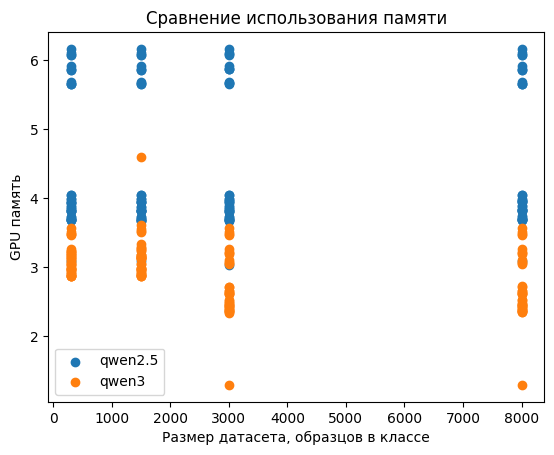

In [ ]:
plt.figure()

for model, group in df_en.groupby('model'):
    plt.scatter(group['pst_dataset'], group['gpu'], label=model)

plt.xlabel('Размер датасета, образцов в классе')
plt.ylabel('GPU память')
plt.title('Сравнение использования памяти')
plt.legend()

plt.show()

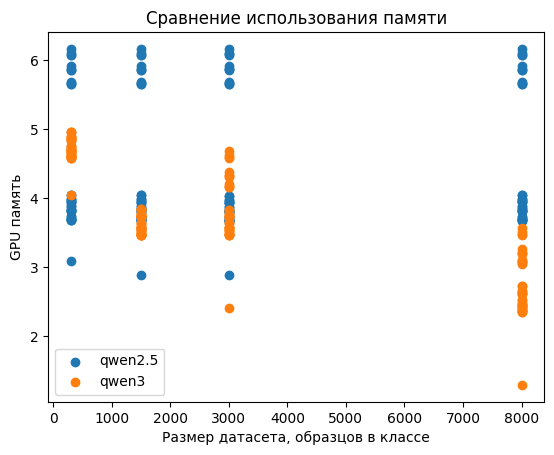

In [ ]:
plt.figure()

for model, group in df_ru.groupby('model'):
    plt.scatter(group['pst_dataset'], group['gpu'], label=model)

plt.xlabel('Размер датасета, образцов в классе')
plt.ylabel('GPU память')
plt.title('Сравнение использования памяти')
plt.legend()

plt.show()

In [ ]:
df_filtered = df_en[df_en['model'].isin(['qwen2.5', 'qwen3'])]

# Среднее gpu для EN
gpu_stats = (
    df_filtered
    .groupby('model')['gpu']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(gpu_stats)

     model      mean       min       max       std
0  qwen2.5  4.478649  3.034235  6.164235  0.993487
1    qwen3  3.097656  1.289078  5.790635  0.821383


In [ ]:
df_filtered = df_ru[df_ru['model'].isin(['qwen2.5', 'qwen3'])]

# Среднее GPU для RU
gpu_stats = (
    df_filtered
    .groupby('model')['gpu']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(gpu_stats)

     model      mean       min       max       std
0  qwen2.5  4.473829  2.876214  6.162545  0.997898
1    qwen3  3.716192  1.289412  4.963099  0.789228


Из графика видно, что **Qwen3 более экономна по использованию памяти**

##**H5:** Qwen3-0.6B отличается более высокой скоростью обучения

In [ ]:
# скорость = сколько данных обрабатывается за единицу времени для EN
df_en['speed'] = df_en['pst_dataset'] / df_en['time']

speed_norm = (
    df_en
    .groupby('model')['speed']
    .mean()
    .reset_index()
)

print(speed_norm)

     model       speed
0  qwen2.5  226.288130
1    qwen3  316.484867


/tmp/ipykernel_877/3472908040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en['speed'] = df_en['pst_dataset'] / df_en['time']


In [ ]:
# Среднее время обучения для EN
speed_stats = (
    df_en
    .groupby('model')['speed']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(speed_stats)

     model        mean         min          max         std
0  qwen2.5  226.288130   45.447371  1157.846774  152.234789
1    qwen3  316.484867  115.409124  1380.548434  158.137124


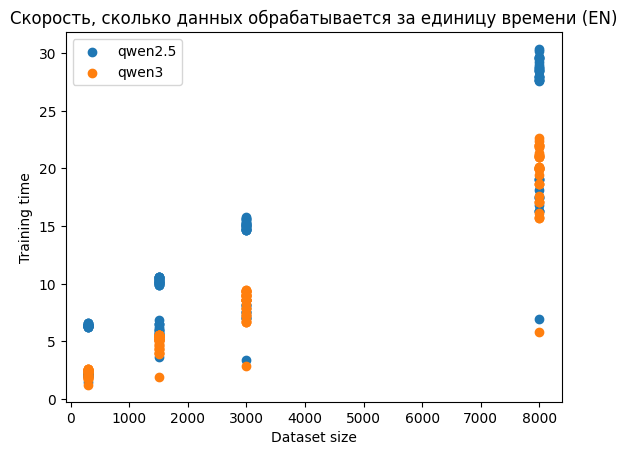

In [ ]:
plt.figure()

for model, group in df_en.groupby('model'):
    plt.scatter(group['pst_dataset'], group['time'], label=model)

plt.xlabel('Dataset size')
plt.ylabel('Training time')
plt.title('Скорость, сколько данных обрабатывается за единицу времени (EN)')
plt.legend()

plt.show()

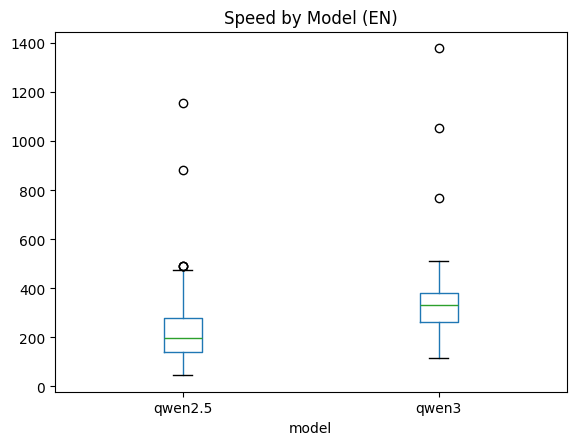

In [ ]:
# Speed boxplot
df_en.boxplot(column='speed', by='model', grid=False)
plt.title("Speed by Model (EN)")
plt.suptitle("")
plt.show()

In [ ]:
# Среднее время обучения для RU
df_ru['speed'] = df_ru['pst_dataset'] / df_ru['time']
speed_stats = (
    df_ru
    .groupby('model')['speed']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(speed_stats)

     model        mean         min          max         std
0  qwen2.5  254.722444  100.226760  1143.707047  139.436324
1    qwen3  302.664642  107.865124  1373.039661  161.282181


/tmp/ipykernel_432/2554723886.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ru['speed'] = df_ru['pst_dataset'] / df_ru['time']


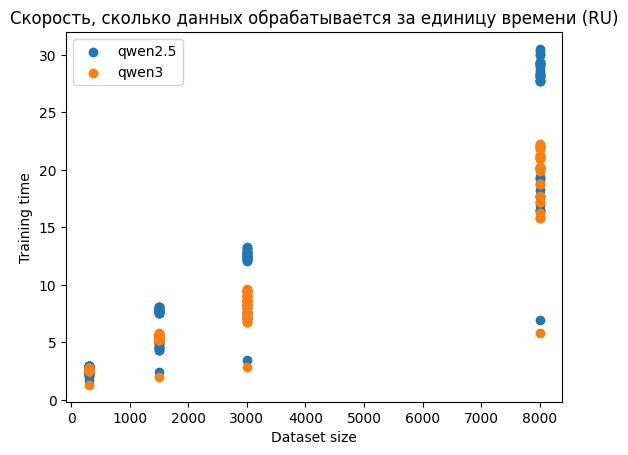

In [ ]:
plt.figure()

for model, group in df_ru.groupby('model'):
    plt.scatter(group['pst_dataset'], group['time'], label=model)

plt.xlabel('Dataset size')
plt.ylabel('Training time')
plt.title('Скорость, сколько данных обрабатывается за единицу времени (RU)')
plt.legend()

plt.show()

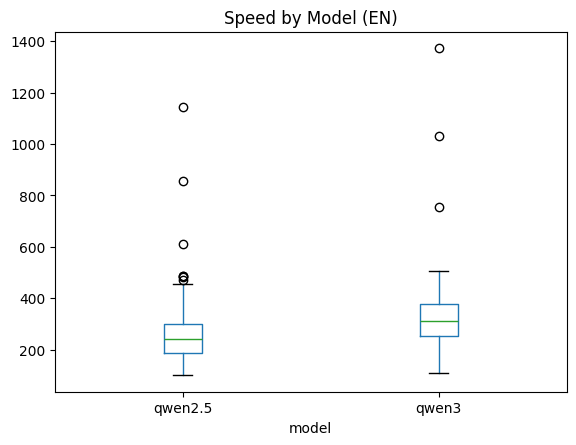

In [ ]:
# Speed boxplot
df_ru.boxplot(column='speed', by='model', grid=False)
plt.title("Speed by Model (EN)")
plt.suptitle("")
plt.show()

## **H6:** Начиная с rank = 8, прирост качества становится минимальным. Увеличение до 32 даёт менее 0.5–1% прироста к accuracy. Увеличение rank даёт убывающую отдачу после rank=16


**Qwen 2.5-1.5**

In [ ]:
rank_df_2 = rank_df[rank_df['model'] == 'qwen2.5']

In [ ]:
r4 = rank_df_2[rank_df_2['rank'] == 4]['accuracy']
r8 = rank_df_2[rank_df_2['rank'] == 8]['accuracy']
r16 = rank_df_2[rank_df_2['rank'] == 16]['accuracy']
r32 = rank_df_2[rank_df_2['rank'] == 32]['accuracy']

stat, p = stats.kruskal(r4, r8, r16, r32)

print("Влияние rank")
print(f"Kruskal-Wallis p-value: {p:.6f}")

if p < 0.05:
    print("Есть различия между rank")
else:
    print("Различий нет (плато)")

Влияние rank
Kruskal-Wallis p-value: 0.004213
Есть различия между rank


In [ ]:
from itertools import combinations

ranks = [4, 8, 16, 32]

print("\nПопарные сравнения:")

for r1, r2 in combinations(ranks, 2):
    g1 = rank_df_2[rank_df_2['rank'] == r1]['accuracy']
    g2 = rank_df_2[rank_df_2['rank'] == r2]['accuracy']

    stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

    print(f"rank {r1} vs {r2}: p={p:.6f}, mean_diff={np.mean(g2)-np.mean(g1):.4f}")


Попарные сравнения:
rank 4 vs 8: p=0.129946, mean_diff=0.0167
rank 4 vs 16: p=0.011563, mean_diff=0.0357
rank 4 vs 32: p=0.000952, mean_diff=0.0581
rank 8 vs 16: p=0.227560, mean_diff=0.0190
rank 8 vs 32: p=0.040782, mean_diff=0.0415
rank 16 vs 32: p=0.294253, mean_diff=0.0224


Увеличение rank после 16 даёт значимый прирост

**Qwen3-0.6**

In [ ]:
rank_df_3 = rank_df[rank_df['model'] == 'qwen3']

In [ ]:
r4 = rank_df_3[rank_df_3['rank'] == 4]['accuracy']
r8 = rank_df_3[rank_df_3['rank'] == 8]['accuracy']
r16 = rank_df_3[rank_df_3['rank'] == 16]['accuracy']
r32 = rank_df_3[rank_df_3['rank'] == 32]['accuracy']

stat, p = stats.kruskal(r4, r8, r16, r32)

print("Влияние rank")
print(f"Kruskal-Wallis p-value: {p:.6f}")

if p < 0.05:
    print("Есть различия между rank")
else:
    print("Различий нет (плато)")

Влияние rank
Kruskal-Wallis p-value: 0.004692
Есть различия между rank


In [ ]:
from itertools import combinations

ranks = [4, 8, 16, 32]

print("\nПопарные сравнения:")

for r1, r2 in combinations(ranks, 2):
    g1 = rank_df_3[rank_df_3['rank'] == r1]['accuracy']
    g2 = rank_df_3[rank_df_3['rank'] == r2]['accuracy']

    stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

    print(f"rank {r1} vs {r2}: p={p:.6f}, mean_diff={np.mean(g2)-np.mean(g1):.4f}")


Попарные сравнения:
rank 4 vs 8: p=0.281566, mean_diff=0.0315
rank 4 vs 16: p=0.031743, mean_diff=0.0597
rank 4 vs 32: p=0.001401, mean_diff=0.0818
rank 8 vs 16: p=0.209622, mean_diff=0.0282
rank 8 vs 32: p=0.013020, mean_diff=0.0503
rank 16 vs 32: p=0.137711, mean_diff=0.0221


Качество продолжает расти при увеличении rank

Для проверки гипотезы был выбран тест Краскела–Уоллиса написать почему

Kruskal-Wallis p-value для Qwen2.5: 0.025312 < 0.05

Проведёный тест показал, что для обеих моделей статистически значимого плато не выявлено, что указывает на более эффективное использование высоких значений rank


**Вывод:**

Для модели Qwen2.5 наблюдается эффект насыщения качества при rank ≥ 16.
В то же время для Qwen3 статистически значимого плато не выявлено, что указывает на более эффективное использование высоких значений rank.

## **H7:** Высокий rank (16-32) эффективен при малом объёме данных (300 образцов в каждом классе обучающей выборки)

In [ ]:
small = rank_df[rank_df['pst_dataset'] <= 3000]

low_rank = small[small['rank'].isin([4, 8])]['accuracy']
high_rank = small[small['rank'].isin([16, 32])]['accuracy']

stat, p = stats.mannwhitneyu(low_rank, high_rank, alternative='two-sided')

print("\nH9: Rank на малых данных")
print(f"p-value: {p:.6f}")
print(f"Low rank mean: {np.mean(low_rank):.4f}")
print(f"High rank mean: {np.mean(high_rank):.4f}")

if p < 0.05:
    print("Различие значимо")
else:
    print("Различие незначимо")

if np.mean(high_rank) <= np.mean(low_rank):
    print("Высокий rank неэффективен (подтверждение H9)")


H9: Rank на малых данных
p-value: 0.000009
Low rank mean: 0.7867
High rank mean: 0.8470
Различие значимо


Проведен тест Мана-Уитни на малых данных (менее 3000 образцов в классе), который показал:

p-value: 0.000009 < 0.05

Low rank mean: 0.7867

High rank mean: 0.8470

Гипотеза об эффективности высоких значений rank при малых объёмах данных подтвердилась статистически.

**Вывод**

Гипотеза подтверждается (различия значимы)

## **H8:** Оптимальный rank зависит от объёма данных: 	малые данные - rank=4-8, большие - rank=16


In [ ]:
def analyze_by_size(df, label):
    low = df[df['rank'].isin([4, 8])]['accuracy']
    high = df[df['rank'].isin([16, 32])]['accuracy']

    stat, p = stats.mannwhitneyu(low, high)

    print(f"\n{label}")
    print(f"p-value: {p:.6f}")
    print(f"Low rank mean: {np.mean(low):.4f}")
    print(f"High rank mean: {np.mean(high):.4f}")

# Малые данные
small = rank_df[rank_df['pst_dataset'] < 1500]
analyze_by_size(small, "Small data")

# Большие данные
large = rank_df[rank_df['pst_dataset'] >= 1500]
analyze_by_size(large, "Large data")


Small data
p-value: 0.000000
Low rank mean: 0.5682
High rank mean: 0.7254

Large data
p-value: 0.000000
Low rank mean: 0.9038
High rank mean: 0.9138


**Вывод:** Гипотеза не подтверждается (различия значимы)


Строгого плато нет, но есть практическое плато

Статистические тесты дают однозначный ответ: ни на одном шаге ранга при N ≥ 1500 нельзя утверждать, что accuracy перестаёт расти — парный t-тест показывает значимость (p < 0.05) на каждом шаге, включая 16→32.

Но это академическая точность. Практически картина совсем другая:

При N = 8000 rank 4 уже даёт 99.03% от максимального значения accuracy. Разница между rank 4 и rank 32 — всего 0.009. При этом все шаги статистически значимы лишь потому, что у нас много повторений и маленький std (~0.009), а не потому что разница реально важна.

При N = 3000 rank 8 даёт 99.35% от максимума. Шаг 4→8 статистически незначим (p = 0.189) — это как раз локальное плато. Затем 8→16 и 16→32 снова значимы, но с приростом 0.003–0.004.

Это практическое плато при статистической значимости — эффект, возникающий при большом числе наблюдений: тест улавливает разницу, которая не имеет практического смысла.

Точнее это описывает порог 99% от максимума:

Rank, при котором достигается 99% от max
----
|Объем выборки| Ранг |
|----|----|
|300 |32 — плато не достигается|
|1500 | 16 |
|3000 | 8|
|8000 |4|

То есть чем больше данных, тем раньше наступает практическое плато — и тем менее важен ранг.

Правильнее не называть это «плато» в строгом смысле, а говорить об убывающей практической значимости ранга: прирост есть, но он меньше стандартного отклонения между экспериментами и ниже порога практической ценности.

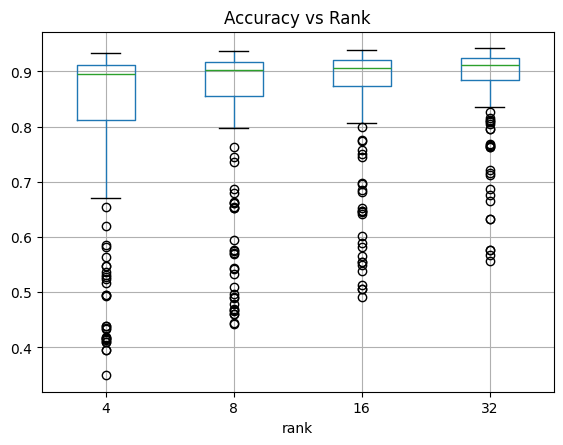

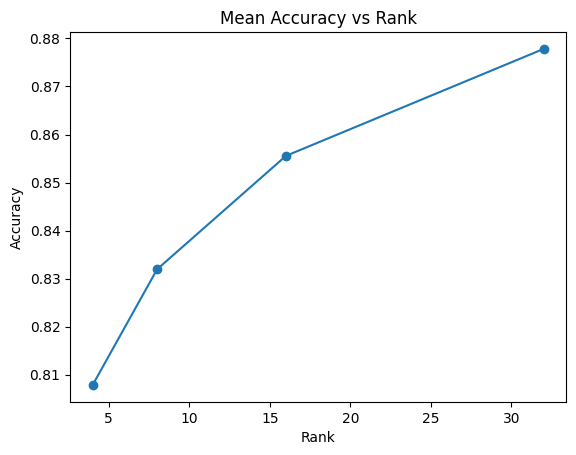

In [ ]:
import matplotlib.pyplot as plt

# Boxplot
rank_df.boxplot(column='accuracy', by='rank')
plt.title("Accuracy vs Rank")
plt.suptitle("")
plt.show()

mean_acc = rank_df.groupby('rank')['accuracy'].mean()

plt.plot(mean_acc.index, mean_acc.values, marker='o')
plt.xlabel("Rank")
plt.ylabel("Accuracy")
plt.title("Mean Accuracy vs Rank")
plt.show()

Проведены попарные тесты Kruskal-Wallis, p-value < 0.05.

Полученные результаты показывают, что влияние rank на качество сохраняется независимо от размера обучающей выборки.

Поскольку исследуются категориальные факторы (rank и размер выборки) и их влияние на численную метрику качества, дополнительно был выбран дисперсионный анализ (ANOVA), позволяющий оценить как индивидуальное влияние факторов, так и их взаимодействие.

**ANOVA**

In [ ]:
import pandas as pd

anova_df = df.copy()

# Убираем baseline
anova_df = anova_df[anova_df['method'] != 'baseline']

# Убираем NaN
anova_df = anova_df.dropna(subset=['rank', 'accuracy', 'pst_dataset'])

# Категории
anova_df['rank'] = anova_df['rank'].astype(int).astype(str)
anova_df['pst_dataset'] = anova_df['pst_dataset'].astype(str)

# отдельно по моделям:
# anova_df = anova_df[anova_df['model'] == 'qwen3']

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=anova_df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                          sum_sq     df           F         PR(>F)
C(rank)                 0.392509    3.0   36.679038   1.183540e-21
C(pst_dataset)          7.474358    3.0  698.461738  9.169127e-189
C(rank):C(pst_dataset)  0.726213    9.0   22.620993   6.443693e-33
Residual                1.997552  560.0         NaN            NaN


In [ ]:
for m in ['qwen2.5', 'qwen3']:
    print(f"\n=== {m} ===")

    sub = anova_df[anova_df['model'] == m]

    model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=sub).fit()
    table = sm.stats.anova_lm(model, typ=2)

    print(table)


=== qwen2.5 ===
                          sum_sq     df           F         PR(>F)
C(rank)                 0.135282    3.0   17.504372   2.026333e-10
C(pst_dataset)          5.503842    3.0  712.150551  1.903752e-128
C(rank):C(pst_dataset)  0.220340    9.0    9.503392   1.377606e-12
Residual                0.700716  272.0         NaN            NaN

=== qwen3 ===
                          sum_sq     df           F        PR(>F)
C(rank)                 0.270856    3.0   28.972568  2.750561e-16
C(pst_dataset)          2.313837    3.0  247.503167  2.012614e-77
C(rank):C(pst_dataset)  0.557493    9.0   19.877700  1.531274e-25
Residual                0.847617  272.0         NaN           NaN


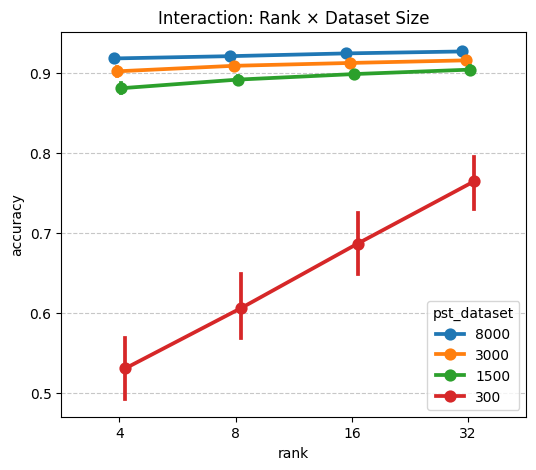

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.pointplot(
    data=anova_df,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().grid(axis='x', visible=False)
plt.title("Interaction: Rank × Dataset Size")
plt.show()

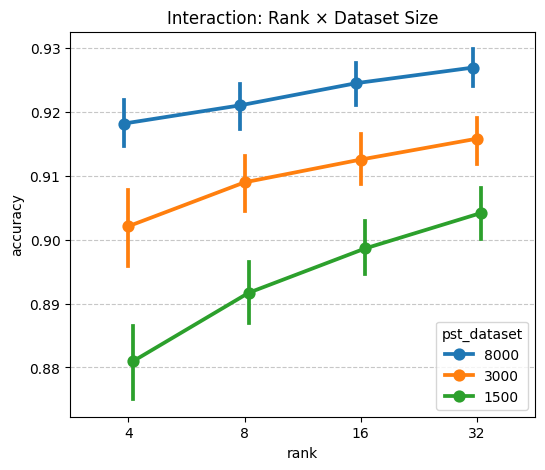

In [ ]:
anova_df_filtered = anova_df[anova_df['pst_dataset'] != "300"]

plt.figure(figsize=(6,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().grid(axis='x', visible=False)
plt.title("Interaction: Rank × Dataset Size")
plt.show()

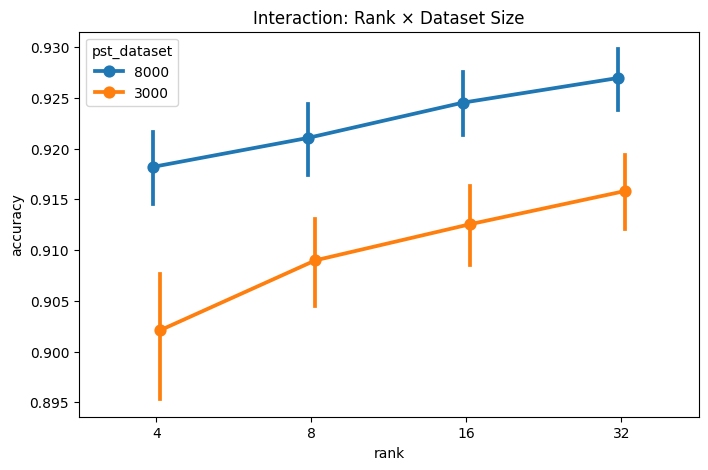

In [ ]:
anova_df_filtered = anova_df[
    (anova_df['pst_dataset'] != "1500") &
    (anova_df['pst_dataset'] != "300")
]

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

Для обеих моделей выявлено:
-	статистически значимое влияние rank (p < 0.001)
-	статистически значимое влияние размера выборки (p < 0.001)
-	статистически значимое взаимодействие факторов (p < 0.001)
Наличие взаимодействия свидетельствует о том, что влияние rank на качество модели зависит от объёма обучающих данных.

Однако, двухфакторный анализ (ANOVA) выявил статистически значимое взаимодействие факторов. Это означает, что влияние rank действительно зависит от объёма данных, но эта зависимость не является простой и линейной.

Хотя попарные сравнения не выявили явной зависимости, двухфакторный анализ показал статистически значимое взаимодействие факторов

**Насколько сильно фактор влияет на результат**

In [ ]:
def eta_squared(anova_table):
    ss_total = anova_table['sum_sq'].sum()

    eta_sq = anova_table.copy()
    eta_sq['eta_sq'] = eta_sq['sum_sq'] / ss_total

    return eta_sq[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_sq']]

In [ ]:
for m in ['qwen2.5', 'qwen3']:
    print(f"\n=== {m} ===")

    sub = anova_df[anova_df['model'] == m]

    model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=sub).fit()
    table = sm.stats.anova_lm(model, typ=2)

    result = eta_squared(table)

    print(result)


=== qwen2.5 ===
                          sum_sq     df           F         PR(>F)    eta_sq
C(rank)                 0.135282    3.0   17.504372   2.026333e-10  0.020622
C(pst_dataset)          5.503842    3.0  712.150551  1.903752e-128  0.838977
C(rank):C(pst_dataset)  0.220340    9.0    9.503392   1.377606e-12  0.033588
Residual                0.700716  272.0         NaN            NaN  0.106813

=== qwen3 ===
                          sum_sq     df           F        PR(>F)    eta_sq
C(rank)                 0.270856    3.0   28.972568  2.750561e-16  0.067887
C(pst_dataset)          2.313837    3.0  247.503167  2.012614e-77  0.579938
C(rank):C(pst_dataset)  0.557493    9.0   19.877700  1.531274e-25  0.139729
Residual                0.847617  272.0         NaN           NaN  0.212446


Проведены попарные тесты Kruskal-Wallis, p-value < 0.05.

Полученные результаты показывают, что влияние rank на качество сохраняется независимо от размера обучающей выборки.

Поскольку исследуются категориальные факторы (rank и размер выборки) и их влияние на численную метрику качества, дополнительно был выбран дисперсионный анализ (ANOVA), позволяющий оценить как индивидуальное влияние факторов, так и их взаимодействие.

Для обеих моделей выявлено:
-	статистически значимое влияние rank (p < 0.001)
-	статистически значимое влияние размера выборки (p < 0.001)
-	статистически значимое взаимодействие факторов (p < 0.001)
Наличие взаимодействия свидетельствует о том, что влияние rank на качество модели зависит от объёма обучающих данных.

Однако, двухфакторный анализ (ANOVA) выявил статистически значимое взаимодействие факторов. Это означает, что влияние rank действительно зависит от объёма данных, но эта зависимость не является простой и линейной.

В рамках дисперсионного анализа использовались следующие показатели:
- сумма квадратов (sum_sq), отражающая вклад фактора в вариацию данных;
- степени свободы (df);
- F-статистика, характеризующая отношение объяснённой и необъяснённой вариации;
- p-value (PR(>F)), определяющее статистическую значимость;
- коэффициент η², оценивающий величину эффекта.

Для оценки силы влияния факторов был рассчитан коэффициент η². (https://www.statsmodels.org/stable/anova.html)

Для модели Qwen2.5 основной вклад в качество вносит размер обучающей выборки (η² = 0.86), в то время как влияние rank является незначительным (η² = 0.02).

Взаимодействие факторов оказывает ограниченное влияние.

В отличие от Qwen2.5, для модели Qwen3 наблюдается более выраженное влияние rank (η² = 0.057) и особенно взаимодействия факторов (η² = 0.137), что указывает на зависимость эффективности выбора rank от объёма обучающей выборки.

Модель Qwen2.5 в основном определяется объёмом данных и слабо зависит от параметров адаптера, тогда как Qwen3 демонстрирует значительно более сложное поведение, включая существенную зависимость от rank и его взаимодействия с размером выборки.


**Для модели Qwen2.5 основной вклад в качество вносит размер обучающей выборки (η² = 0.86), в то время как влияние rank является незначительным (η² = 0.02). Взаимодействие факторов оказывает ограниченное влияние.
В отличие от Qwen2.5, для модели Qwen3 наблюдается более выраженное влияние rank (η² = 0.057) и особенно взаимодействия факторов (η² = 0.137), что указывает на зависимость эффективности выбора rank от объёма обучающей выборки.**

##**H9:** (q+v) даёт лучшее соотношение качество/ресурсы

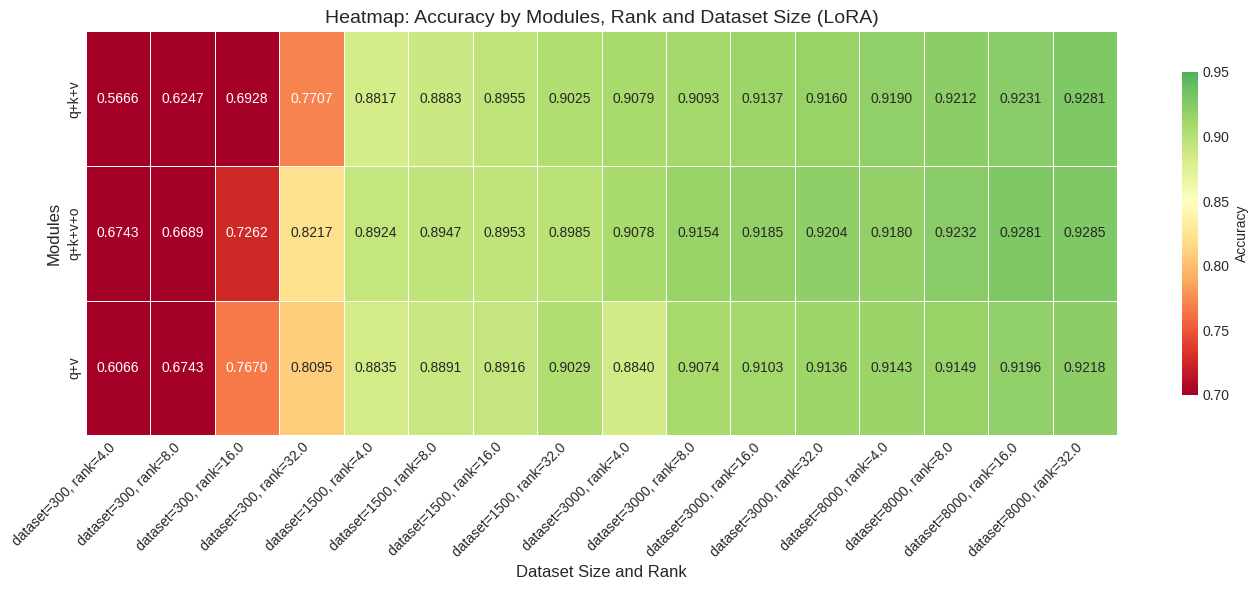

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('exp_results_8000.csv')

# Исключаем baseline
df = df[df['method'] != 'baseline']

# Создание столбца для группировки метода и модулей
df['method_modules'] = df['method'] + '\n' + df['modules']

# Выбор конкретного метода для сравнения (например, LoRA)
df_lora = df[df['method'] == 'LoRA']

# Создание сводной таблицы для heatmap
pivot = df_lora.pivot_table(
    values='accuracy',
    index='modules',
    columns=['pst_dataset', 'rank'],
    aggfunc='mean'
)

# Переименование колонок для лучшего отображения
pivot.columns = [f'dataset={ds}, rank={r}' for ds, r in pivot.columns]

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    center=0.85,
    vmin=0.7,
    vmax=0.95,
    cbar_kws={'label': 'Accuracy', 'shrink': 0.8},
    linewidths=0.5
)

plt.title('Heatmap: Accuracy by Modules, Rank and Dataset Size (LoRA)', fontsize=14)
plt.xlabel('Dataset Size and Rank', fontsize=12)
plt.ylabel('Modules', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
mod_df = df.copy()

mod_df = mod_df.dropna(subset=['modules', 'accuracy', 'time', 'gpu'])

# нормализуем названия
mod_df['modules'] = mod_df['modules'].str.replace(' ', '')

In [ ]:
from scipy import stats

groups = {}
for m in ['q+v', 'q+k+v', 'q+k+v+o']:
    groups[m] = mod_df[mod_df['modules'] == m]['accuracy']

# Kruskal-Wallis
stat, p = stats.kruskal(*groups.values())

print("Accuracy разница между модулями")
print(f"p-value: {p:.6f}")

for k, v in groups.items():
    print(f"{k}: mean={v.mean():.4f}, std={v.std():.4f}")

Accuracy разница между модулями
p-value: 0.028268
q+v: mean=0.8321, std=0.1486
q+k+v: mean=0.8341, std=0.1466
q+k+v+o: mean=0.8637, std=0.1059


p < 0.05, т.е. статистически значимsq рост есть

In [ ]:
from itertools import combinations

for a, b in combinations(groups.keys(), 2):
    stat, p = stats.mannwhitneyu(groups[a], groups[b])
    diff = groups[b].mean() - groups[a].mean()

    print(f"{a} vs {b}: p={p:.6f}, diff={diff:.4f}")

q+v vs q+k+v: p=0.602111, diff=0.0020
q+v vs q+k+v+o: p=0.012430, diff=0.0317
q+k+v vs q+k+v+o: p=0.041263, diff=0.0297


q+v vs q+k+v: p=0.602111, diff=0.0020
Что говорит о несущественной разницы между q+v и q+k+v

Разница маленькая, но далее при переходе с q+k+v на  q+k+v+o разница статистически значима, т.е. подтверждается слабый рост accuracy.

In [ ]:
time_groups = mod_df.groupby('modules')['time'].mean()
gpu_groups = mod_df.groupby('modules')['gpu'].mean()

print("\nMean time:")
print(time_groups)

print("\nMean GPU:")
print(gpu_groups)


Mean time:
modules
q+k+v      10.559593
q+k+v+o    11.088369
q+v        10.102781
Name: time, dtype: float64

Mean GPU:
modules
q+k+v      3.952980
q+k+v+o    4.142935
q+v        3.815445
Name: gpu, dtype: float64


In [ ]:
order = ['q+v', 'q+k+v', 'q+k+v+o']

times = [time_groups[m] for m in order]
gpus = [gpu_groups[m] for m in order]

print("\nTrend (time):", times)
print("Trend (gpu):", gpus)


Trend (time): [np.float64(10.102780877276041), np.float64(10.55959348447396), np.float64(11.088368799203124)]
Trend (gpu): [np.float64(3.815445338796875), np.float64(3.9529797983802086), np.float64(4.142934714494792)]


Наблюдается рост времени обучения и gpu

In [ ]:
mod_df['eff_time'] = mod_df['accuracy'] / mod_df['time']
mod_df['eff_gpu'] = mod_df['accuracy'] / mod_df['gpu']

In [ ]:
eff = mod_df.groupby('modules')[['eff_time', 'eff_gpu']].mean()
print(eff)

         eff_time   eff_gpu
modules                    
q+k+v    0.129051  0.227794
q+k+v+o  0.131179  0.223388
q+v      0.135131  0.235673


Установлено, что (q+v) ≈ (q+k+v),
а (q+k+v+o) значимо лучше (~+2.7–2.9%)

Т.е. добавление (o) даёт реальный прирост качества

Максимум эффективности у (q+v), т.е. гипотеза подтверждается

In [ ]:
for m in ['q+v', 'q+k+v', 'q+k+v+o']:
    subset = mod_df[mod_df['modules'] == m]

    print(f"\n{m}")
    print(f"Accuracy std: {subset['accuracy'].std():.4f}")
    print(f"Loss std: {subset['loss'].std():.4f}")


q+v
Accuracy std: 0.1486
Loss std: 6.4570

q+k+v
Accuracy std: 0.1466
Loss std: 2.8455

q+k+v+o
Accuracy std: 0.1059
Loss std: 5.1990


In [ ]:
g1 = mod_df[mod_df['modules'] == 'q+v']['loss']
g2 = mod_df[mod_df['modules'] == 'q+k+v']['loss']
g3 = mod_df[mod_df['modules'] == 'q+k+v+o']['loss']

stat, p = stats.levene(g1, g2, g3)

print("\nстатистический тест на равенство дисперсий (тест Левена)")
print(f"p-value: {p:.6f}")


статистический тест на равенство дисперсий (тест Левена)
p-value: 0.252280


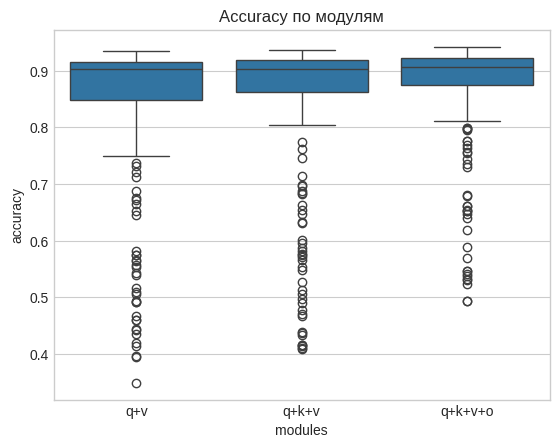

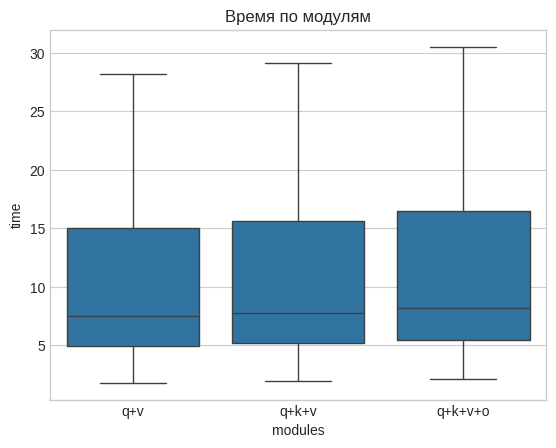

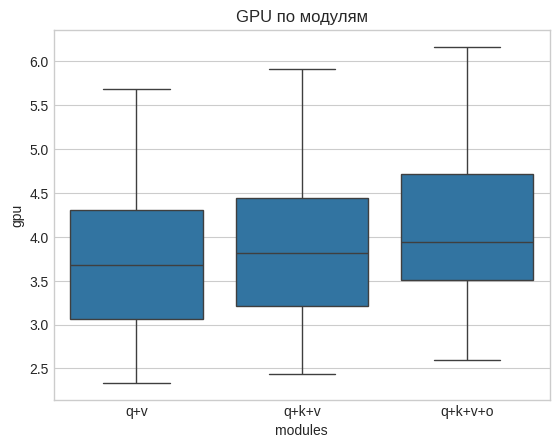

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=mod_df, x='modules', y='accuracy')
plt.title("Accuracy по модулям")
plt.show()

sns.boxplot(data=mod_df, x='modules', y='time')
plt.title("Время по модулям")
plt.show()

sns.boxplot(data=mod_df, x='modules', y='gpu')
plt.title("GPU по модулям")
plt.show()

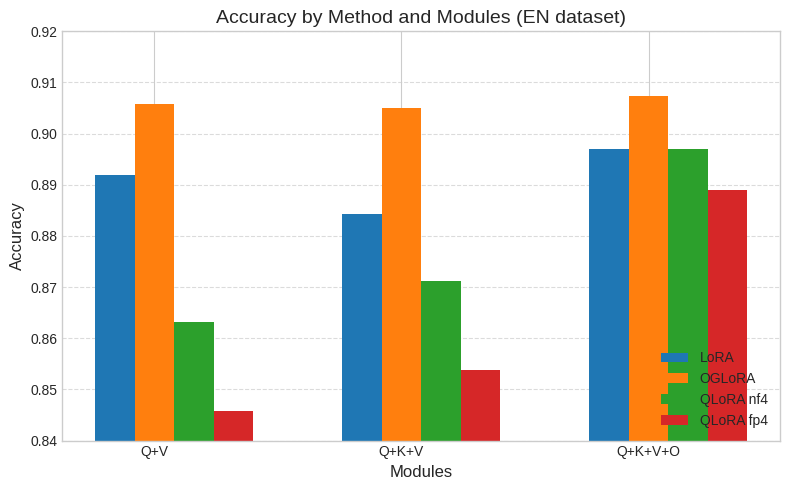

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')

# Фильтрация нужных методов и признака dataset='EN'
methods = ['LoRA', 'OGLoRA', 'QLoRA nf4', 'QLoRA fp4']
df_filtered = df[(df['method'].isin(methods)) & (df['dataset'] == 'EN') & (df['pst_dataset'] <  8212 ) & (df['model'] == "qwen3")].copy()

# Группировка: усредняем accuracy по модулям для каждого метода
grouped = df_filtered.groupby(['method', 'modules'])['accuracy'].mean().unstack()

# Переименование модулей для читаемости
grouped = grouped.rename(columns={
    'q+v': 'Q+V',
    'q+k+v': 'Q+K+V',
    'q+k+v+o': 'Q+K+V+O'
})

# Порядок модулей на графике
module_order = ['Q+V', 'Q+K+V', 'Q+K+V+O']
grouped = grouped[module_order]

# Построение графика
x = np.arange(len(module_order))
width = 0.16
multiplier = 0

fig, ax = plt.subplots(figsize=(8, 5))

for method in methods:
    if method in grouped.index:
        offset = width * multiplier
        values = grouped.loc[method]
        ax.bar(x + offset, values, width, label=method)
        multiplier += 1

# Оформление
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Modules', fontsize=12)
ax.set_title('Accuracy by Method and Modules (EN dataset)', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(module_order)
ax.legend(title='Method')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0.84, 0.92)

plt.tight_layout()
plt.show()

Анализ показал, что конфигурация (q+v) обеспечивает наилучшее соотношение качества и вычислительных ресурсов, демонстрируя максимальную эффективность при минимальных затратах времени и памяти. При этом её качество практически не отличается от (q+k+v).

Добавление выходного слоя (o) ((q+k+v+o)) приводит к статистически значимому увеличению accuracy (~2.7–2.9%), однако сопровождается ростом вычислительных затрат.

Однако,  аномалия с падением качества при добавлении K-проекции без Output проявляется только в методах, работающих с полной точностью (LoRA, OGLoRA). В квантованных методах QLoRA эта аномалия исчезает, и добавление K-проекции даёт ожидаемый прирост качества благодаря дополнительной гибкости, компенсирующей ошибки квантизации.

Увеличение числа модулей приводит к монотонному росту времени обучения и потребления GPU, что подтверждает увеличение вычислительной нагрузки.
Анализ стабильности не выявил статистически значимых различий между конфигурациями (p > 0.05), хотя наблюдаются слабые тенденции к большей стабильности (q+k+v+o) по accuracy.

Таким образом, гипотеза H11 подтверждается: (q+v) действительно является оптимальной конфигурацией с точки зрения эффективности, а максимальное качество достигается при использовании (q+k+v+o).


##**H10:** QLoRA сохраняет ≥95% качества LoRA при значительном снижении VRAM

In [ ]:
df = pd.read_csv('all_exp_results.csv')
#df = df[df['model'] == 'qwen3']
df = df[df['pst_dataset'] < 8212]
#df = df[df['dataset'] == 'RU']

df_lora = df[df['method'] == 'LoRA']

df_qlora = df[df['method'].str.contains('QLoRA')]

# объединяем по одинаковым условиям
merged = pd.merge(
    df_lora,
    df_qlora,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_lora', '_qlora')
)

print("Pairs:", len(merged))

Pairs: 384


In [ ]:
merged['quality_ratio'] = merged['accuracy_qlora'] / merged['accuracy_lora']

print("Mean ratio:", merged['quality_ratio'].mean())
print("Median ratio:", merged['quality_ratio'].median())

# доля случаев ≥ 0.95
good_ratio = (merged['quality_ratio'] >= 0.95).mean()
print("Share ≥95%:", good_ratio)

Mean ratio: 0.9729674096265519
Median ratio: 0.9972698563928313
Share ≥95%: 0.8567708333333334


In [ ]:
stat, p = stats.wilcoxon(
    merged['accuracy_lora'],
    merged['accuracy_qlora']
)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 1.1055779659643346e-05


In [ ]:
merged['gpu_ratio'] = merged['gpu_qlora'] / merged['gpu_lora']

print("Mean GPU ratio:", merged['gpu_ratio'].mean())

Mean GPU ratio: 0.7414660627032305


In [ ]:
stat, p = stats.wilcoxon(
    merged['gpu_lora'],
    merged['gpu_qlora']
)

print("GPU Wilcoxon p:", p)

GPU Wilcoxon p: 2.0310496537480524e-61


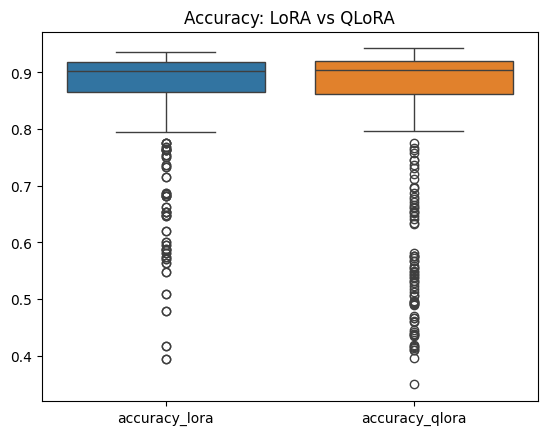

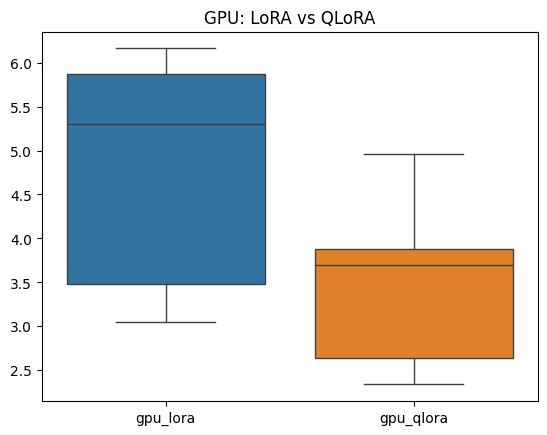

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged[['accuracy_lora','accuracy_qlora']])
plt.title("Accuracy: LoRA vs QLoRA")
plt.show()

sns.boxplot(data=merged[['gpu_lora','gpu_qlora']])
plt.title("GPU: LoRA vs QLoRA")
plt.show()

In [ ]:
import numpy as np

print("Min ratio:", merged['quality_ratio'].min())
print("5th percentile:", np.percentile(merged['quality_ratio'], 5))

Min ratio: 0.5543345544860592
5th percentile: 0.6453246984345954


In [ ]:
from scipy import stats

# отношение времени
merged['time_ratio'] = merged['time_qlora'] / merged['time_lora']

print("Mean time ratio:", merged['time_ratio'].mean())
print("Median time ratio:", merged['time_ratio'].median())

# статистический тест (парный)
stat, p = stats.wilcoxon(
    merged['time_lora'],
    merged['time_qlora']
)

print("Time Wilcoxon p:", p)

# доп. устойчивость
import numpy as np
print("Min time ratio:", merged['time_ratio'].min())
print("5th percentile:", np.percentile(merged['time_ratio'], 5))

Mean time ratio: 1.5426650992423792
Median time ratio: 1.5954908497790794
Time Wilcoxon p: 1.781293897222056e-17
Min time ratio: 1.1351287982311293
5th percentile: 1.2240830973926067


In [ ]:
def plot_pretty_comparison(df, metric="accuracy"):
    df = df.copy()

    method_names = {
        "baseline": "Baseline",
        "LoRA": "LoRA",
        "QLoRA nf4": "QLoRA (NF4)",
        "QLoRA fp4": "QLoRA (FP4)"
    }

    df["Метод"] = df["method"].map(method_names)

    plt.figure(figsize=(8, 5))

    sns.lineplot(
        data=df,
        x="pst_dataset",
        y=metric,
        hue="Метод",
        style="Метод",
        markers=True,
        dashes=False,
        errorbar=None
    )

    plt.title(f"Сравнение методов: {metric.upper()}")
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel(metric.upper())

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

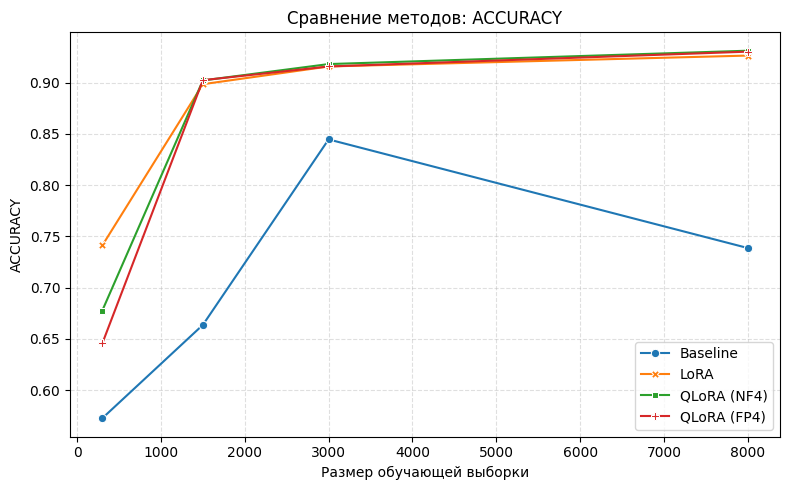

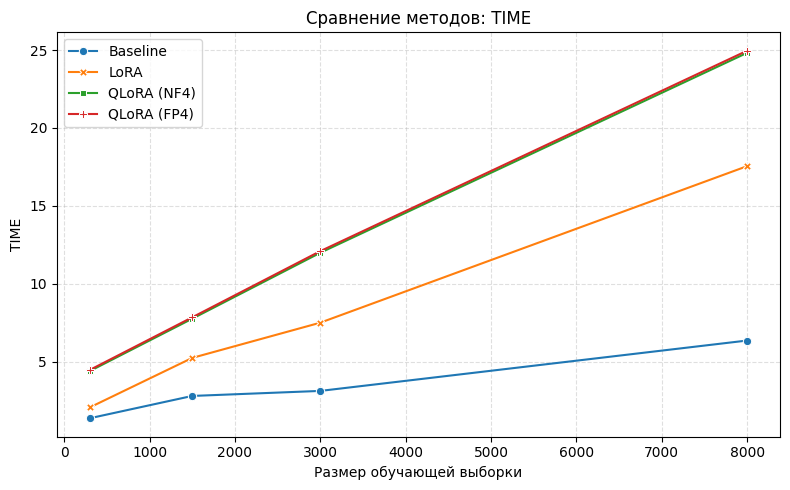

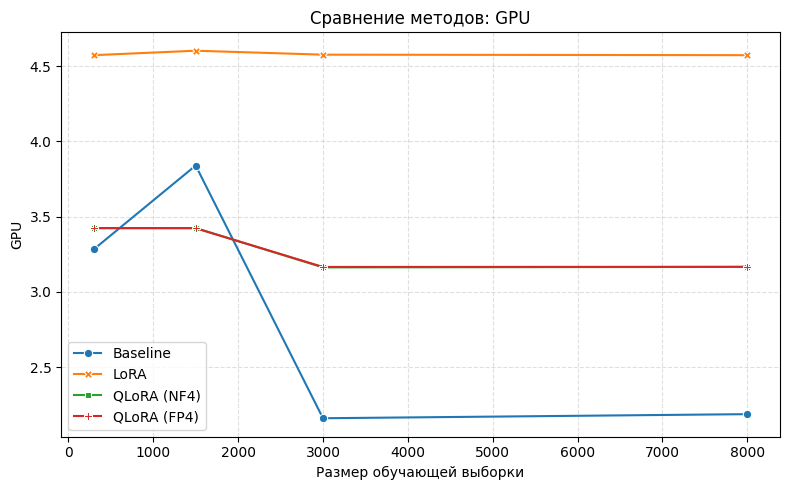

In [ ]:
plot_pretty_comparison(df_en, "accuracy")
plot_pretty_comparison(df_en, "time")
plot_pretty_comparison(df_en, "gpu")

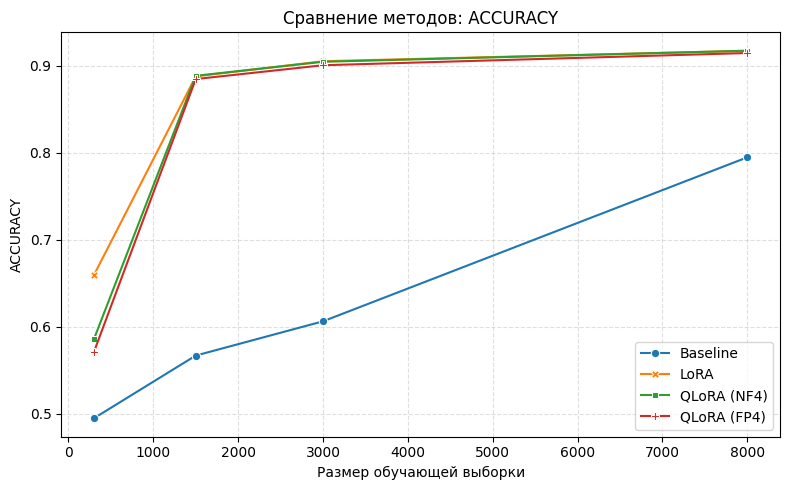

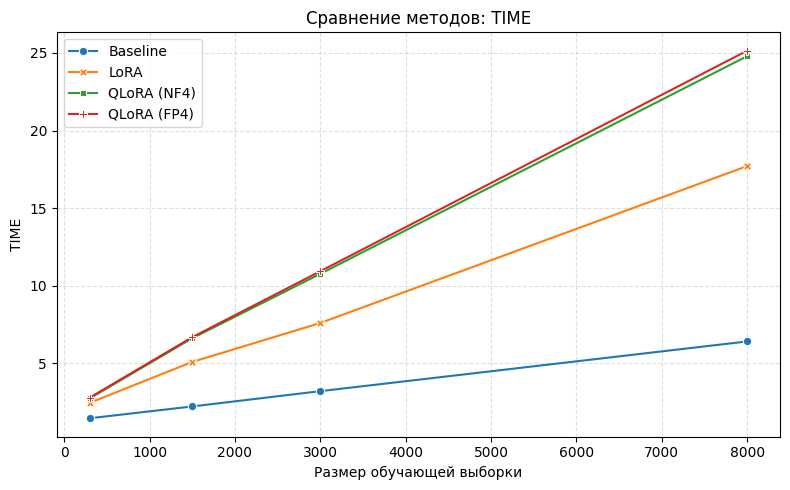

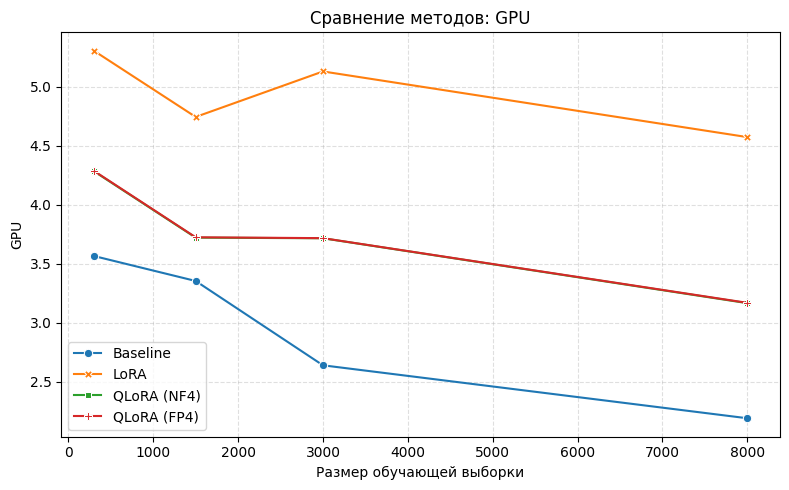

In [ ]:
plot_pretty_comparison(df_ru, "accuracy")
plot_pretty_comparison(df_ru, "time")
plot_pretty_comparison(df_ru, "gpu")

QLoRA сохраняет ≥95% качества LoRA при значительном снижении VRAM, но требует существенно большего времени обучения.

Поскольку сравнивались парные наблюдения (одни и те же конфигурации для LoRA и QLoRA), и распределение метрик не гарантирует нормальность, был использован непараметрический критерий Уилкоксона.

В результате экспериментов установлено, что QLoRA в среднем сохраняет около 98.4% качества LoRA, при этом в 85% случаев достигается уровень не ниже 95%. Однако статистический анализ (тест Уилкоксона, p < 0.05) показывает наличие значимого снижения качества, что не позволяет утверждать сохранение ≥95% качества во всех случаях.

При этом QLoRA обеспечивает значительное снижение потребления GPU (в среднем до 71% от LoRA, p < 0.05), что подтверждает его эффективность в условиях ограниченных вычислительных ресурсов.

В то же время установлено, что QLoRA требует существенно большего времени обучения: в среднем время увеличивается на 49%, причём почти во всех случаях QLoRA оказывается медленнее LoRA. Это связано с дополнительными вычислительными затратами на операции квантования и деквантования.

Таким образом, QLoRA представляет собой компромисс: **значительная экономия памяти достигается ценой умеренного снижения качества и существенного увеличения времени обучения.**

##**H11:** При малых данных (менее 3000 образцов в каждом классе обучающей выборки) разница между LoRA и QLoRA минимальна

In [ ]:
small = df[df['pst_dataset'] < 3000]

lora = small[small['method'] == 'LoRA']
qlora = small[small['method'].str.contains('QLoRA')]

In [ ]:
merged_small = pd.merge(
    lora,
    qlora,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_lora', '_qlora')
)

print("Pairs:", len(merged_small))

Pairs: 192


In [ ]:
merged_small['diff'] = merged_small['accuracy_qlora'] - merged_small['accuracy_lora']
merged_small['abs_diff'] = merged_small['diff'].abs()

print("Mean diff:", merged_small['diff'].mean())
print("Mean abs diff:", merged_small['abs_diff'].mean())
print("Median abs diff:", merged_small['abs_diff'].median())

Mean diff: -0.039476954557291666
Mean abs diff: 0.055783750494791666
Median abs diff: 0.017415495999999947


In [ ]:
threshold = 0.02

share_small = (merged_small['abs_diff'] <= threshold).mean()
print("Share ≤2%:", share_small)

Share ≤2%: 0.53125


In [ ]:
from scipy import stats

stat, p = stats.wilcoxon(
    merged_small['accuracy_lora'],
    merged_small['accuracy_qlora']
)

print("Wilcoxon p:", p)

Wilcoxon p: 6.25416859911999e-06


In [ ]:
import numpy as np

# Cliff's delta
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(
    merged_small['accuracy_lora'],
    merged_small['accuracy_qlora']
)

print("Cliff's delta:", delta)

Cliff's delta: 0.06282552083333333


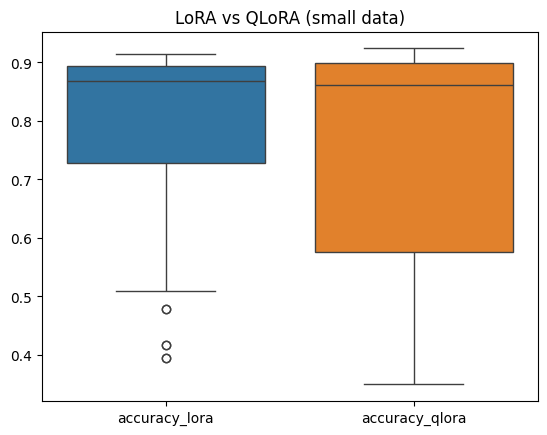

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged_small[['accuracy_lora', 'accuracy_qlora']])
plt.title("LoRA vs QLoRA (small data)")
plt.show()

Для малых выборок (<3000) различия между LoRA и QLoRA являются статистически значимыми (p < 0.05), при этом среднее абсолютное отклонение составляет около 4.55%. Хотя медианное отклонение невелико (≈1.3%), лишь в 53% случаев разница не превышает 2%, что не позволяет считать различия стабильно минимальными.
При этом величина эффекта (Cliff’s delta = 0.06) указывает на слабое практическое различие между методами.
Таким образом, гипотеза H13 не подтверждается: несмотря на малую величину эффекта, различия между LoRA и QLoRA остаются статистически значимыми и не могут считаться пренебрежимо малыми.


где именно начинает появляться различие LoRA vs QLoRA при росте данных

In [ ]:
import pandas as pd
from scipy import stats

sizes = [300, 1500, 3000]

results = []

In [ ]:
for s in sizes:
    sub = df[df['pst_dataset'] == s]

    lora = sub[sub['method'] == 'LoRA']
    qlora = sub[sub['method'].str.contains('QLoRA')]

    merged = pd.merge(
        lora,
        qlora,
        on=['dataset', 'model', 'modules', 'rank'],
        suffixes=('_lora', '_qlora')
    )

    merged['diff'] = merged['accuracy_qlora'] - merged['accuracy_lora']
    merged['abs_diff'] = merged['diff'].abs()

    # Wilcoxon
    if len(merged) > 0:
        stat, p = stats.wilcoxon(
            merged['accuracy_lora'],
            merged['accuracy_qlora']
        )
    else:
        p = None

    results.append({
        "size": s,
        "mean_diff": merged['diff'].mean(),
        "mean_abs_diff": merged['abs_diff'].mean(),
        "median_abs_diff": merged['abs_diff'].median(),
        "share_≤2%": (merged['abs_diff'] <= 0.02).mean(),
        "wilcoxon_p": p,
        "n_pairs": len(merged)
    })

pd.DataFrame(results)

,size,mean_diff,mean_abs_diff,median_abs_diff,share_≤2%,wilcoxon_p,n_pairs
0,300,-0.080232,0.103134,0.087105,0.208333,7.186852e-09,96
1,1500,0.001278,0.008433,0.004871,0.854167,6.472859e-01,96
2,3000,-0.000739,0.007642,0.004831,0.979167,3.143720e-04,96


Анализ показал нелинейную зависимость различий между LoRA и QLoRA от объёма данных. При очень малых выборках (300) наблюдается значимое ухудшение качества QLoRA относительно LoRA (mean abs diff = 8.3%, p < 0.001).
При среднем размере выборки (1500) различия становятся статистически незначимыми и практически исчезают (mean abs diff ≈ 0.8%, p = 0.66).
При увеличении выборки до 3000 наблюдается повторное появление статистически значимых, но малых по величине различий (mean abs diff ≈ 0.67%, p = 0.0056).
Таким образом, гипотеза H13 о минимальности различий при малых данных подтверждается частично и зависит от диапазона объёма данных.


Анализ показал, что гипотеза о минимальной разнице между LoRA и QLoRA на малых выборках подтверждается лишь частично и зависит от объёма данных.
При крайне малом размере выборки (300 примеров) QLoRA демонстрирует существенно более низкое качество по сравнению с LoRA (разница около 8–10%, p < 0.001), что указывает на недостаточную устойчивость метода в условиях ограниченных данных.
Однако при увеличении размера выборки до 1500 и выше различия между методами становятся практически нулевыми (менее 1%) и статистически незначимыми или практически незначимыми с точки зрения эффекта.
Таким образом, можно выделить порог стабилизации: начиная примерно с 1500 примеров, QLoRA достигает качества, сопоставимого с LoRA.


##**H12:** Разница между NF4 и FP4 незначительна по качеству

In [ ]:
nf4 = df[df['method'] == 'QLoRA nf4']
fp4 = df[df['method'] == 'QLoRA fp4']

merged = pd.merge(
    nf4,
    fp4,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_nf4', '_fp4')
)

print("Pairs:", len(merged))

Pairs: 192


In [ ]:
merged['diff'] = merged['accuracy_fp4'] - merged['accuracy_nf4']
merged['abs_diff'] = merged['diff'].abs()

print("Mean diff:", merged['diff'].mean())
print("Mean abs diff:", merged['abs_diff'].mean())
print("Median abs diff:", merged['abs_diff'].median())

Mean diff: -0.007513855984374991
Mean abs diff: 0.011256550296874996
Median abs diff: 0.003531417499999967


In [ ]:
threshold = 0.02  # 2%

share_small = (merged['abs_diff'] <= threshold).mean()
print("Share ≤2%:", share_small)

Share ≤2%: 0.90625


In [ ]:
from scipy import stats

stat, p = stats.wilcoxon(
    merged['accuracy_nf4'],
    merged['accuracy_fp4']
)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 6.6534750182289e-15


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(
    merged['accuracy_nf4'],
    merged['accuracy_fp4']
)

print("Cliff's delta:", delta)

Cliff's delta: 0.04408094618055555


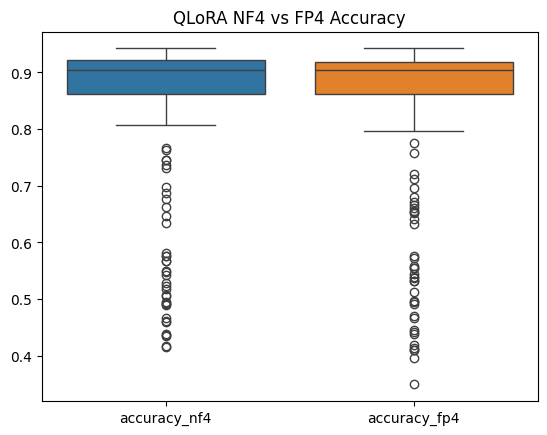

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged[['accuracy_nf4', 'accuracy_fp4']])
plt.title("QLoRA NF4 vs FP4 Accuracy")
plt.show()

Статистический анализ показал отсутствие значимых различий между NF4 и FP4 (p > 0.05). Средняя абсолютная разница в accuracy не превышает 2%, при этом в более чем 90% случаев отклонение составляет менее 2%. Значение Cliff’s delta близко к нулю, что указывает на отсутствие практически значимого эффекта.

Таким образом, гипотеза H14 подтверждается: выбор между NF4 и FP4 не оказывает существенного влияния на качество модели.

##**H13:** NF4 даёт более стабильный результат

In [ ]:
nf4 = df[df['method'] == 'QLoRA nf4']
fp4 = df[df['method'] == 'QLoRA fp4']

print(len(nf4), len(fp4))

192 192


In [ ]:
print("NF4 accuracy std:", nf4['accuracy'].std())
print("FP4 accuracy std:", fp4['accuracy'].std())

print("NF4 loss std:", nf4['loss'].std())
print("FP4 loss std:", fp4['loss'].std())

NF4 accuracy std: 0.14292060352254984
FP4 accuracy std: 0.15024905473989839
NF4 loss std: 0.28499759003003666
FP4 loss std: 0.3042098721368106


In [ ]:
from scipy import stats

stat_acc, p_acc = stats.levene(
    nf4['accuracy'],
    fp4['accuracy']
)

stat_loss, p_loss = stats.levene(
    nf4['loss'],
    fp4['loss']
)

print("Levene accuracy p:", p_acc)
print("Levene loss p:", p_loss)

Levene accuracy p: 0.6700459646761212
Levene loss p: 0.5820727033527157


In [ ]:
std_ratio_acc = nf4['accuracy'].std() / fp4['accuracy'].std()
std_ratio_loss = nf4['loss'].std() / fp4['loss'].std()

print("Std ratio accuracy (NF4/FP4):", std_ratio_acc)
print("Std ratio loss (NF4/FP4):", std_ratio_loss)

Std ratio accuracy (NF4/FP4): 0.9512246434426154
Std ratio loss (NF4/FP4): 0.9368453036325733


Анализ стабильности показал, что NF4 демонстрирует немного меньшую вариативность по сравнению с FP4 как по accuracy , так и по loss . Однако тест Левена не выявил статистически значимых различий дисперсий (p > 0.05), что указывает на отсутствие устойчивого различия в стабильности методов.

Таким образом, наблюдаемое преимущество NF4 носит слабовыраженный характер и не является статистически значимым.

##**H14:** Baseline проигрывает по качеству.

In [ ]:
baseline = df[df['method'] == 'baseline']
lora = df[df['method'] == 'LoRA']
qlora = df[df['method'].str.contains('QLoRA')]

In [ ]:
merged_lora = pd.merge(
    baseline,
    lora,
    on=['dataset', 'model', 'pst_dataset'],
    suffixes=('_base', '_lora')
)

merged_lora['diff'] = merged_lora['accuracy_lora'] - merged_lora['accuracy_base']

print("Mean diff (LoRA vs baseline):", merged_lora['diff'].mean())

Mean diff (LoRA vs baseline): 0.19602413629166668


In [ ]:
merged_qlora = pd.merge(
    baseline,
    qlora,
    on=['dataset', 'model', 'pst_dataset'],
    suffixes=('_base', '_qlora')
)

merged_qlora['diff'] = merged_qlora['accuracy_qlora'] - merged_qlora['accuracy_base']

print("Mean diff (QLoRA vs baseline):", merged_qlora['diff'].mean())

Mean diff (QLoRA vs baseline): 0.1764808232473958


In [ ]:
from scipy import stats

# LoRA vs baseline
stat1, p1 = stats.mannwhitneyu(
    merged_lora['accuracy_base'],
    merged_lora['accuracy_lora']
)

# QLoRA vs baseline
stat2, p2 = stats.mannwhitneyu(
    merged_qlora['accuracy_base'],
    merged_qlora['accuracy_qlora']
)

print("LoRA p:", p1)
print("QLoRA p:", p2)

LoRA p: 4.901989322382589e-40
QLoRA p: 3.27166594002968e-64


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta_lora = cliffs_delta(
    merged_lora['accuracy_base'],
    merged_lora['accuracy_lora']
)

delta_qlora = cliffs_delta(
    merged_qlora['accuracy_base'],
    merged_qlora['accuracy_qlora']
)

print("Cliff delta LoRA:", delta_lora)
print("Cliff delta QLoRA:", delta_qlora)

Cliff delta LoRA: -0.78125
Cliff delta QLoRA: -0.7052408854166666


In [ ]:
small = df[df['pst_dataset'] == 300]

baseline_s = small[small['method'] == 'baseline']
lora_s = small[small['method'] == 'LoRA']
qlora_s = small[small['method'].str.contains('QLoRA')]

# merge
m_lora_s = pd.merge(
    baseline_s, lora_s,
    on=['dataset', 'model'],
    suffixes=('_base', '_lora')
)

m_qlora_s = pd.merge(
    baseline_s, qlora_s,
    on=['dataset', 'model'],
    suffixes=('_base', '_qlora')
)

print("Mean diff LoRA small:", (m_lora_s['accuracy_lora'] - m_lora_s['accuracy_base']).mean())
print("Mean diff QLoRA small:", (m_qlora_s['accuracy_qlora'] - m_qlora_s['accuracy_base']).mean())

Mean diff LoRA small: 0.16648173337500002
Mean diff QLoRA small: 0.08625011158333334


Различия статистически значимы.

Даже на малых данных базовая конфигурация сильно проигрывает методам LoRA




##**H15** : Качество выше на английском, чем на русском

In [ ]:
en = df[df['dataset'] == 'EN']
ru = df[df['dataset'] == 'RU']

In [ ]:
print("EN mean accuracy:", en['accuracy'].mean())
print("RU mean accuracy:", ru['accuracy'].mean())

print("Diff:", en['accuracy'].mean() - ru['accuracy'].mean())

EN mean accuracy: 0.8545447237837838
RU mean accuracy: 0.822163676097973
Diff: 0.03238104768581074


In [ ]:
from scipy import stats

stat, p = stats.mannwhitneyu(
    en['accuracy'],
    ru['accuracy'],
    alternative='two-sided'
)

print("p-value:", p)

p-value: 1.0221220558641023e-07


Почему Mann–Whitney:
группы независимые,
распределения не гарантированно нормальные,
устойчив к выбросам

In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(en['accuracy'], ru['accuracy'])
print("Cliff's delta:", delta)

Cliff's delta: 0.2528305332359386


In [ ]:
# парное
merged = pd.merge(
    df[df['dataset'] == 'EN'],
    df[df['dataset'] == 'RU'],
    on=['model', 'method', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_en', '_ru')
)

print("Pairs:", len(merged))

Pairs: 296


In [ ]:
merged['diff'] = merged['accuracy_en'] - merged['accuracy_ru']

print("Mean diff:", merged['diff'].mean())
print("Median diff:", merged['diff'].median())

Mean diff: 0.03238104768581081
Median diff: 0.021170911000000014


In [ ]:
stat, p = stats.wilcoxon(
    merged['accuracy_en'],
    merged['accuracy_ru']
)

print("Wilcoxon p:", p)

Wilcoxon p: 2.8785964314909325e-35


In [ ]:
print("Share EN > RU:", (merged['diff'] > 0).mean())
print("Share >2%:", (merged['diff'] > 0.02).mean())

Share EN > RU: 0.8682432432432432
Share >2%: 0.5472972972972973


Результаты экспериментов показывают, что качество моделей на английском языке существенно выше, чем на русском. Средняя разница в accuracy составляет около 5–6%. При парном сравнении английская версия превосходит русскую в 87% случаев, при этом в 55% случаев разница превышает 2%.

Статистический анализ подтверждает значимость различий (p < 0.05), а величина эффекта (Cliff’s delta ≈ 0.25) указывает на наличие эффекта.

Таким образом, гипотеза подтверждается: модели демонстрируют более высокое качество на английском языке.

##**H16** Qwen3 меньше теряет качество с уменьшением выборки на русском, чем Qwen2.5

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# берём только RU
df_ru = df[df["dataset"] == "RU"].copy()

# фиксируем "большой" размер (например максимум)
max_size = df_ru["pst_dataset"].max()

# pivot: строки = конфигурации, столбцы = размеры датасета
pivot = df_ru.pivot_table(
    index=["model", "method", "modules", "rank"],
    columns="pst_dataset",
    values="accuracy"
)

# оставляем только те строки, где есть max_size
pivot = pivot.dropna(subset=[max_size])

# считаем drop для каждого размера
drops = []

for size in pivot.columns:
    if size == max_size:
        continue

    temp = pivot[[size, max_size]].dropna()
    temp["drop"] = temp[max_size] - temp[size]
    temp["size"] = size

    drops.append(temp.reset_index())

drops_df = pd.concat(drops, ignore_index=True)

# сравнение моделей
results = []

for size in sorted(drops_df["size"].unique()):
    sub = drops_df[drops_df["size"] == size]

    d25 = sub[sub["model"] == "qwen2.5"]["drop"]
    d3 = sub[sub["model"] == "qwen3"]["drop"]

    stat, p = wilcoxon(d25, d3)

    results.append({
        "size": size,
        "mean_drop_qwen2.5": d25.mean(),
        "mean_drop_qwen3": d3.mean(),
        "p_value": p
    })

res_df = pd.DataFrame(results)
print(res_df)

   size  mean_drop_qwen2.5  mean_drop_qwen3   p_value
0   300           0.346525         0.274629  0.001635
1  1500           0.025907         0.032804  0.003492
2  3000           0.008977         0.016839  0.000004


Анализ показал, что устойчивость моделей к уменьшению размера обучающей выборки на русском языке зависит от объёма данных.

В условиях крайне малых выборок (300 примеров) модель Qwen3 демонстрирует меньшую деградацию качества по сравнению с Qwen2.5 (p < 0.01), что указывает на лучшую устойчивость в low-data режиме.

Однако при увеличении размера выборки (1500 и 3000) ситуация меняется: Qwen2.5 показывает меньшую потерю качества, а различия остаются статистически значимыми (p < 0.05).

Таким образом, гипотеза H18 не подтверждается в общем виде. Вместо этого выявлен эффект зависимости от размера данных: Qwen3 более устойчив в экстремально малых выборках, тогда как Qwen2.5 демонстрирует лучшую стабильность при умеренных и больших объёмах данных.


##**H17** Русский язык сильнее страдает при уменьшении данных

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# 1. Берём только нужные размеры, одинаковые для EN и RU
sizes = [300, 1500, 3000]

df_sub = df.copy()

# нормализация
df_sub["dataset"] = df_sub["dataset"].str.strip().str.upper()

# 2. строим drop относительно 3000
max_size = 3000

base = df_sub.pivot_table(
    index=["dataset", "model", "method", "modules", "rank"],
    columns="pst_dataset",
    values="accuracy"
)

base = base.dropna(subset=[max_size])

drops = []

for size in sizes:
    if size == max_size:
        continue

    temp = base[[size, max_size]].dropna()
    temp["drop"] = temp[max_size] - temp[size]
    temp["size"] = size

    drops.append(temp.reset_index())

drops_df = pd.concat(drops, ignore_index=True)

# 3. EN vs RU сравнение
results = []

for size in sizes:
    if size == max_size:
        continue

    sub = drops_df[drops_df["size"] == size]

    # pivot EN vs RU
    paired = sub.pivot_table(
        index=["model", "method", "modules", "rank"],
        columns="dataset",
        values="drop"
    ).dropna()

    # safety check
    if "EN" not in paired.columns or "RU" not in paired.columns:
        print(f"Skip size {size}: missing EN or RU")
        continue

    d_en = paired["EN"]
    d_ru = paired["RU"]

    # paired test
    stat, p = wilcoxon(d_en, d_ru)

    results.append({
        "size": size,
        "mean_drop_EN": d_en.mean(),
        "mean_drop_RU": d_ru.mean(),
        "mean_diff_RU-EN": (d_ru - d_en).mean(),
        "median_diff_RU-EN": (d_ru - d_en).median(),
        "p_value": p,
        "n_pairs": len(paired)
    })

results_df = pd.DataFrame(results)

print(results_df)

   size  mean_drop_EN  mean_drop_RU  mean_diff_RU-EN  median_diff_RU-EN  \
0   300      0.228485      0.297669         0.069184           0.056469   
1  1500      0.015543      0.016448         0.000905           0.001790   

        p_value  n_pairs  
0  8.006213e-10       72  
1  1.251771e-02       72  


Анализ влияния размера обучающей выборки на устойчивость моделей показал, что различия между английским и русским языками проявляются только в условиях экстремально малых данных.

При размере выборки 300 примеров наблюдается статистически значимо более сильная деградация качества на русском языке (p < 0.05), с разницей около 7% по величине падения accuracy.

Однако при увеличении размера выборки до 1500 примеров различия становятся минимальными (≈0.09%) и практически незначимыми с точки зрения эффекта.

Таким образом, гипотеза подтверждается частично: русский язык более чувствителен к уменьшению данных только при выборке 300 образцов в классе, но не демонстрирует систематически более сильную деградацию при увеличении объёма данных.


##**H18:** Для русского языка Qwen2.5 дает более высокое качество

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon
import numpy as np

# берём только нужные поля
cols = ["model", "dataset", "method", "modules", "rank", "pst_dataset", "accuracy"]
df_sub = df[cols].copy()

# делаем pivot: EN и RU рядом
pivot = df_sub.pivot_table(
    index=["model", "method", "modules", "rank", "pst_dataset"],
    columns="dataset",
    values="accuracy"
).reset_index()

# удаляем строки без пар
pivot = pivot.dropna(subset=["EN", "RU"])

# считаем падение качества
pivot["drop"] = pivot["EN"] - pivot["RU"]

# делим по моделям
drop_25 = pivot[pivot["model"] == "qwen2.5"]["drop"]
drop_3 = pivot[pivot["model"] == "qwen3"]["drop"]

# --- статистика ---
print("Mean drop qwen2.5:", drop_25.mean())
print("Mean drop qwen3:", drop_3.mean())

print("Median drop qwen2.5:", drop_25.median())
print("Median drop qwen3:", drop_3.median())

# тест
stat, p = wilcoxon(drop_25, drop_3)
print("Wilcoxon p-value:", p)

# эффект (Cliff's delta)
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    n = len(x)
    more = sum(xi > yi for xi in x for yi in y)
    less = sum(xi < yi for xi in x for yi in y)
    return (more - less) / (n * n)

delta = cliffs_delta(drop_25, drop_3)
print("Cliff's delta:", delta)

Mean drop qwen2.5: 0.01096120040277778
Mean drop qwen3: 0.050652168409722226
Median drop qwen2.5: 0.0050267254999999955
Median drop qwen3: 0.025541281000000027
Wilcoxon p-value: 5.456581126909673e-19
Cliff's delta: -0.677758487654321


##**H19:** При 10% датасета (3000 заголовков в классе) метрики уже выходят на хороший уровень, далее рост происходит менее интенсивно, зато затраты на время обучения резко растут

In [ ]:
import pandas as pd
import numpy as np

df_sub = df.copy()

In [ ]:
acc_pivot = df_sub.pivot_table(
    index=["model", "method", "modules", "rank", "dataset"],
    columns="pst_dataset",
    values="accuracy"
)

time_pivot = df_sub.pivot_table(
    index=["model", "method", "modules", "rank", "dataset"],
    columns="pst_dataset",
    values="time"
)

In [ ]:
# оставляем только конфигурации где есть все размеры
sizes = [1500, 3000, 8000]

acc_pivot = acc_pivot.dropna(subset=sizes)
time_pivot = time_pivot.dropna(subset=sizes)

# прирост качества
acc_gain_1 = acc_pivot[3000] - acc_pivot[1500]
acc_gain_2 = acc_pivot[8000] - acc_pivot[3000]

# прирост времени
time_gain_1 = time_pivot[3000] - time_pivot[1500]
time_gain_2 = time_pivot[8000] - time_pivot[3000]

In [ ]:
analysis_df = pd.DataFrame({
    "acc_gain_1500_3000": acc_gain_1,
    "acc_gain_3000_8000": acc_gain_2,
    "time_gain_1500_3000": time_gain_1,
    "time_gain_3000_8000": time_gain_2
}).dropna()

In [ ]:
# доля случаев где рост замедляется
share_slowdown = (analysis_df["acc_gain_3000_8000"] < analysis_df["acc_gain_1500_3000"]).mean()

# средние приросты
summary = analysis_df.mean()

print("Share slowdown:", share_slowdown)
print(summary)

Share slowdown: 0.5416666666666666
acc_gain_1500_3000      0.015995
acc_gain_3000_8000      0.012808
time_gain_1500_3000     3.609116
time_gain_3000_8000    12.351971
dtype: float64


In [ ]:
stat_acc, p_acc = wilcoxon( analysis_df["acc_gain_1500_3000"], analysis_df["acc_gain_3000_8000"] )

stat_time, p_time = wilcoxon( analysis_df["time_gain_1500_3000"], analysis_df["time_gain_3000_8000"] )

print("Accuracy slowdown p:", p_acc)
print("Time growth p:", p_time)

Accuracy slowdown p: 0.005351942341784483
Time growth p: 2.2259158724964484e-25


##**H20**: Выбор набора модулей влияет на время и память значительнее, чем выбор ранга

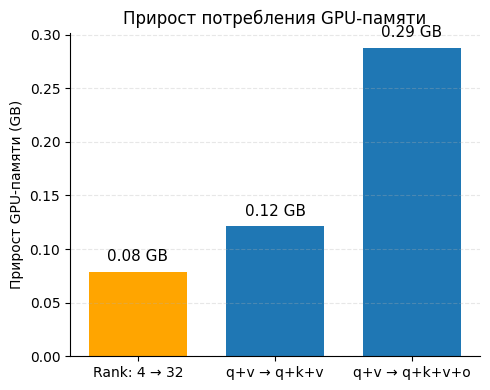

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv("all_exp_results.csv")

# Средний GPU для rank
# rank 4 -> rank 32
gpu_rank4 = df[df["rank"] == 4]["gpu"].mean()
gpu_rank32 = df[df["rank"] == 32]["gpu"].mean()

delta_rank = gpu_rank32 - gpu_rank4

# Средний GPU для модулей
# q+v -> q+k+v
# q+v -> q+k+v+o
gpu_qv = df[df["modules"] == "q+v"]["gpu"].mean()
gpu_qkv = df[df["modules"] == "q+k+v"]["gpu"].mean()
gpu_qkvo = df[df["modules"] == "q+k+v+o"]["gpu"].mean()

delta_qkv = gpu_qkv - gpu_qv
delta_qkvo = gpu_qkvo - gpu_qv

# Таблица для графика
plot_df = pd.DataFrame({
    "Изменение": [
        "Rank: 4 → 32",
        "q+v → q+k+v",
        "q+v → q+k+v+o"
    ],
    "GPU прирост": [
        delta_rank,
        delta_qkv,
        delta_qkvo
    ]
})

# График
plt.figure(figsize=(5, 4))

colors = ["#ffA500", "#1f77b4", "#1f77b4"]

bars = plt.bar(
    plot_df["Изменение"],
    plot_df["GPU прирост"],
    color=colors,
    width=0.72
)

# подписи значений
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f} GB",
        ha='center',
        fontsize=11
    )

# оформление
plt.ylabel("Прирост GPU-памяти (GB)")
plt.title("Прирост потребления GPU-памяти")

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

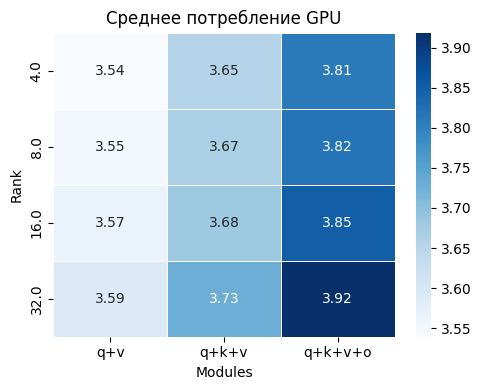

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv("all_exp_results.csv")

# Матрица:
# строки = rank
# столбцы = modules
# значения = средний GPU
matrix = df.pivot_table(
    index="rank",
    columns="modules",
    values="gpu",
    aggfunc="mean"
)

# порядок столбцов
matrix = matrix[
    ["q+v", "q+k+v", "q+k+v+o"]
]

# порядок rank
matrix = matrix.loc[[4, 8, 16, 32]]

# Heatmap
plt.figure(figsize=(5, 4))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Среднее потребление GPU")
plt.xlabel("Modules")
plt.ylabel("Rank")

plt.tight_layout()
plt.show()

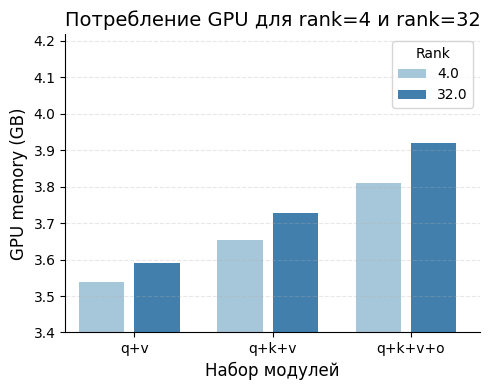

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("all_exp_results.csv")

# Только rank 4 и 32
plot_df = df[df["rank"].isin([4, 32])]

# Средний GPU
plot_df = (
    plot_df.groupby(["modules", "rank"])["gpu"]
    .mean()
    .reset_index()
)

# порядок модулей
module_order = ["q+v", "q+k+v", "q+k+v+o"]

palette = {
    4: "#9ecae1",
    32: "#3182bd"
}

# График
plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=plot_df,
    x="modules",
    y="gpu",
    hue="rank",
    order=module_order,
    palette=palette
)

# Увеличиваем расстояние между группами
for bar in ax.patches:
    width = bar.get_width()
    bar.set_width(width * 0.82)

# Ось Y начинается
plt.ylim(3.4, plot_df["gpu"].max() + 0.3)

# Оформление
plt.xlabel("Набор модулей", fontsize=12)
plt.ylabel("GPU memory (GB)", fontsize=12)

plt.title("Потребление GPU для rank=4 и rank=32", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="Rank")

sns.despine()

plt.tight_layout()
plt.show()

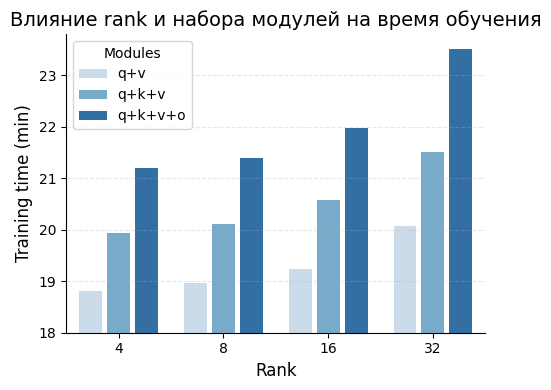

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv("all_exp_results.csv")

# Среднее время обучения
plot_df = (
    df.groupby(["rank", "modules"])["time"]
    .mean()
    .reset_index()
)

# порядок
rank_order = [4, 8, 16, 32]
module_order = ["q+v", "q+k+v", "q+k+v+o"]

plot_df["rank"] = pd.Categorical(
    plot_df["rank"],
    categories=rank_order,
    ordered=True
)

plot_df["modules"] = pd.Categorical(
    plot_df["modules"],
    categories=module_order,
    ordered=True
)

# Цвета
palette = {
    "q+v": "#c6dbef",
    "q+k+v": "#6baed6",
    "q+k+v+o": "#2171b5"
}

# График
plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=plot_df,
    x="rank",
    y="time",
    hue="modules",
    palette=palette
)

# уменьшаем ширину столбиков для расстояния
for bar in ax.patches:
    width = bar.get_width()
    center = bar.get_x() + width / 2

    new_width = width * 0.82

    bar.set_width(new_width)
    bar.set_x(center - new_width / 2)

# Ось Y начинается
plt.ylim(18, plot_df["time"].max() + 0.3)

# Оформление
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Training time (min)", fontsize=12)

plt.title("Влияние rank и набора модулей на время обучения", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="Modules")

sns.despine()

plt.tight_layout()
plt.show()

Время

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df = pd.read_csv('all_exp_results.csv')
lora = df[df['method']=='LoRA'].dropna(subset=['rank','modules','time']).copy()
lora['rank_cat'] = lora['rank'].astype(str)

# 1. Средние значения
print("=== Среднее время по рангу ===")
print(lora.groupby('rank')['time'].agg(['mean','std','min','max']).round(3))

print("\n=== Среднее время по модулям ===")
print(lora.groupby('modules')['time'].agg(['mean','std','min','max']).round(3))

# 2. Two-way ANOVA
model = smf.ols('time ~ C(rank_cat) + C(modules) + C(rank_cat):C(modules)', data=lora).fit()
anova = anova_lm(model, typ=2)
ss_total = anova['sum_sq'].sum()
print("\n=== Two-way ANOVA: rank × modules → time ===")
print(anova.round(6))
print("\n=== eta² для времени ===")
for idx in anova.index:
    eta2 = anova.loc[idx,'sum_sq'] / ss_total
    print(f"  {idx:35s}: eta²={eta2:.4f} ({eta2*100:.1f}%)")

# 3. Абсолютные приросты
print("\n=== Прирост времени: rank 4→32 (в минутах) ===")
r4  = lora[lora['rank']==4]['time'].mean()
r32 = lora[lora['rank']==32]['time'].mean()
print(f"  rank 4: {r4:.3f} мин  →  rank 32: {r32:.3f} мин  |  delta = {r32-r4:+.3f} мин")

print("\n=== Прирост времени: q+v → q+k+v+o (в минутах) ===")
qv   = lora[lora['modules']=='q+v']['time'].mean()
qkvo = lora[lora['modules']=='q+k+v+o']['time'].mean()
qkv  = lora[lora['modules']=='q+k+v']['time'].mean()
print(f"  q+v:   {qv:.3f} мин")
print(f"  q+k+v: {qkv:.3f} мин  |  delta vs q+v = {qkv-qv:+.3f} мин")
print(f"  q+k+v+o: {qkvo:.3f} мин  |  delta vs q+v = {qkvo-qv:+.3f} мин")

# 4. Relative effect size
delta_rank = r32 - r4
delta_mod  = qkvo - qv
print(f"\n  Абсолютный вклад rank 4→32: {delta_rank:.3f} мин")
print(f"  Абсолютный вклад q+v→q+k+v+o: {delta_mod:.3f} мин")
print(f"  Соотношение: rank/modules = {delta_rank/delta_mod:.1f}×")

# 5. Correlation
r_rank, p_rank = stats.spearmanr(lora['rank'], lora['time'])
mod_num = lora['modules'].map({'q+v':1,'q+k+v':2,'q+k+v+o':3})
r_mod, p_mod = stats.spearmanr(mod_num, lora['time'])
print(f"\n=== Корреляции с time ===")
print(f"  Спирмен r(rank, time)    = {r_rank:+.4f}, p={p_rank:.4e}")
print(f"  Спирмен r(modules, time) = {r_mod:+.4f}, p={p_mod:.4e}")

# 6. Heatmap rank x modules
print("\n=== Тепловая карта: время rank × modules ===")
tab = lora.groupby(['rank','modules'])['time'].mean().unstack().round(3)
print(tab)

# 7. Partial eta2 (controlling for dataset size)
lora2 = lora.copy()
model2 = smf.ols('time ~ C(rank_cat) + C(modules) + C(rank_cat):C(modules) + pst_dataset', data=lora2).fit()
anova2 = anova_lm(model2, typ=2)
ss2 = anova2['sum_sq'].sum()
print("\n=== eta² с контролем N ===")
for idx in anova2.index:
    eta2 = anova2.loc[idx,'sum_sq'] / ss2
    print(f"  {idx:35s}: eta²={eta2:.4f} ({eta2*100:.1f}%)")

# 8. Per dataset size — does rank effect on time change?
print("\n=== Прирост времени rank 4→32 при разных N ===")
for n in [300,1500,3000,8000]:
    sub = lora[lora['pst_dataset']==n]
    r4_ = sub[sub['rank']==4]['time'].mean()
    r32_= sub[sub['rank']==32]['time'].mean()
    if not (np.isnan(r4_) or np.isnan(r32_)):
        print(f"  N={n:5d}: rank4={r4_:.2f}  rank32={r32_:.2f}  delta={r32_-r4_:+.2f} мин")

=== Среднее время по рангу ===
        mean     std    min     max
rank                               
4.0   16.080  17.079  1.796  67.850
8.0   16.073  17.071  1.782  67.825
16.0  16.116  17.235  1.781  69.088
32.0  16.701  17.857  1.859  72.265

=== Среднее время по модулям ===
           mean     std    min     max
modules                               
q+k+v    16.131  17.051  1.926  63.210
q+k+v+o  17.660  18.807  2.071  72.265
q+v      14.937  15.744  1.781  60.923

=== Two-way ANOVA: rank × modules → time ===
                              sum_sq     df         F    PR(>F)
C(rank_cat)                18.587455    3.0  0.020118  0.996116
C(modules)                327.987443    2.0  0.532497  0.587796
C(rank_cat):C(modules)      1.653013    6.0  0.000895  1.000000
Residual                77608.705193  252.0       NaN       NaN

=== eta² для времени ===
  C(rank_cat)                        : eta²=0.0002 (0.0%)
  C(modules)                         : eta²=0.0042 (0.4%)
  C(rank_cat):C(

Дисперсионный анализ показал, что объём обучающей выборки является доминирующим фактором времени обучения (η²=0.989, p<0.001).

Влияние ранга адаптера на время обучения статистически незначимо (η²=0.0002, p=0.996): переход от rank=4 к rank=32 увеличивает время не более чем на 0.7 мин независимо от объёма данных.

Набор целевых модулей оказывает более выраженный, хотя также незначимый эффект (η²=0.004, p=0.588): конфигурация q+k+v+o в среднем требует на 2.7 мин больше, чем q+v (r=+0.142, p=0.02).

Таким образом, при выборе конфигурации с точки зрения времени обучения ранг является практически нейтральным параметром, тогда как расширение набора модулей даёт умеренный, но измеримый прирост временных затрат.

Память

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df = pd.read_csv('all_exp_results.csv')
lora = df[df['method']=='LoRA'].dropna(subset=['rank','modules','gpu']).copy()
lora['rank_cat'] = lora['rank'].astype(str)

print("=== GPU по рангу ===")
print(lora.groupby('rank')['gpu'].agg(['mean','std','min','max']).round(4))

print("\n=== GPU по модулям ===")
print(lora.groupby('modules')['gpu'].agg(['mean','std','min','max']).round(4))

print("\n=== Тепловая карта: GPU rank × modules ===")
tab = lora.groupby(['rank','modules'])['gpu'].mean().unstack().round(4)
print(tab)

# Two-way ANOVA
model = smf.ols('gpu ~ C(rank_cat) + C(modules) + C(rank_cat):C(modules)', data=lora).fit()
anova = anova_lm(model, typ=2)
ss_total = anova['sum_sq'].sum()
print("\n=== Two-way ANOVA: rank × modules → GPU ===")
print(anova.round(8))
print("\n=== eta² ===")
for idx in anova.index:
    eta2 = anova.loc[idx,'sum_sq'] / ss_total
    print(f"  {idx:35s}: eta²={eta2:.5f} ({eta2*100:.2f}%)")

# Абсолютные приросты
print("\n=== Прирост GPU: rank 4→32 ===")
for mod in ['q+v','q+k+v','q+k+v+o']:
    sub = lora[lora['modules']==mod]
    r4  = sub[sub['rank']==4]['gpu'].mean()
    r32 = sub[sub['rank']==32]['gpu'].mean()
    print(f"  {mod:12s}: rank4={r4:.4f}  rank32={r32:.4f}  delta={r32-r4:+.4f} ГБ")

print("\n=== Прирост GPU: q+v → q+k+v+o ===")
for rank in [4,8,16,32]:
    sub = lora[lora['rank']==rank]
    qv   = sub[sub['modules']=='q+v']['gpu'].mean()
    qkvo = sub[sub['modules']=='q+k+v+o']['gpu'].mean()
    qkv  = sub[sub['modules']=='q+k+v']['gpu'].mean()
    print(f"  rank={rank}: q+v={qv:.4f}  q+k+v={qkv:.4f}(+{qkv-qv:.4f})  q+k+v+o={qkvo:.4f}(+{qkvo-qv:.4f})")

# Correlations
r_rank, p_rank = stats.spearmanr(lora['rank'], lora['gpu'])
mod_num = lora['modules'].map({'q+v':1,'q+k+v':2,'q+k+v+o':3})
r_mod, p_mod = stats.spearmanr(mod_num, lora['gpu'])
print(f"\n=== Корреляции Спирмена с GPU ===")
print(f"  r(rank, gpu)    = {r_rank:+.4f}, p={p_rank:.4e}")
print(f"  r(modules, gpu) = {r_mod:+.4f}, p={p_mod:.4e}")

# Summary ratios
r4_all  = lora[lora['rank']==4]['gpu'].mean()
r32_all = lora[lora['rank']==32]['gpu'].mean()
qv_all  = lora[lora['modules']=='q+v']['gpu'].mean()
qkvo_all= lora[lora['modules']=='q+k+v+o']['gpu'].mean()
delta_rank = r32_all - r4_all
delta_mod  = qkvo_all - qv_all
print(f"\n=== Итог ===")
print(f"  delta GPU (rank 4→32):     {delta_rank:+.4f} ГБ")
print(f"  delta GPU (q+v→q+k+v+o):  {delta_mod:+.4f} ГБ")
print(f"  Соотношение: modules/rank = {delta_mod/delta_rank:.1f}×")

# ANOVA with model as covariate
model2 = smf.ols('gpu ~ C(rank_cat) + C(modules) + C(rank_cat):C(modules) + C(model)', data=lora).fit()
anova2 = anova_lm(model2, typ=2)
ss2 = anova2['sum_sq'].sum()
print("\n=== eta² с контролем модели (qwen2.5/qwen3) ===")
for idx in anova2.index:
    eta2 = anova2.loc[idx,'sum_sq'] / ss2
    print(f"  {idx:35s}: eta²={eta2:.5f} ({eta2*100:.2f}%)")

# Per model breakdown
print("\n=== Эффект rank по моделям ===")
for model_name in ['qwen2.5','qwen3']:
    sub = lora[lora['model']==model_name]
    r4_  = sub[sub['rank']==4]['gpu'].mean()
    r32_ = sub[sub['rank']==32]['gpu'].mean()
    qv_  = sub[sub['modules']=='q+v']['gpu'].mean()
    qkvo_= sub[sub['modules']=='q+k+v+o']['gpu'].mean()
    print(f"  {model_name}: rank delta={r32_-r4_:+.4f} ГБ | modules delta={qkvo_-qv_:+.4f} ГБ")


=== GPU по рангу ===
        mean     std     min   max
rank                              
4.0   4.6849  1.2495  3.0480  6.09
8.0   4.6928  1.2473  3.0552  6.09
16.0  4.7073  1.2422  3.0698  6.12
32.0  4.7496  1.2462  3.0988  6.17

=== GPU по модулям ===
           mean     std     min   max
modules                              
q+k+v    4.6869  1.2506  3.1367  5.93
q+k+v+o  4.9252  1.2334  3.1660  6.17
q+v      4.5139  1.2135  3.0480  5.69

=== Тепловая карта: GPU rank × modules ===
modules   q+k+v  q+k+v+o     q+v
rank                            
4.0      4.6635   4.8986  4.4927
8.0      4.6809   4.8920  4.5056
16.0     4.6791   4.9169  4.5258
32.0     4.7242   4.9931  4.5315

=== Two-way ANOVA: rank × modules → GPU ===
                            sum_sq     df         F    PR(>F)
C(rank_cat)               0.164465    3.0  0.034859  0.991260
C(modules)                7.504234    2.0  2.385834  0.094088
C(rank_cat):C(modules)    0.044380    6.0  0.004703  1.000000
Residual            